# **Module 1 (Language Detection)**

**Dataset:** papluca/language-identification  
**Task:** Multi-class language classification across 20 languages  
**Approach:** TF-IDF + Classical ML  

## **Part 1: Exploratory Data Analysis**

This part covers deep EDA before any modeling decisions are finalized.  
We answer four critical questions:
1. Is the dataset truly balanced across all languages?
2. What is the text length distribution per language?
3. Which languages share scripts (trivially separable vs. hard pairs)?
4. Which language pairs have the highest character n-gram overlap (hardest to distinguish)?

## 1. Environment Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from itertools import combinations
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from datasets import load_dataset

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Global plot style
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'font.family': 'DejaVu Sans'
})
PALETTE = sns.color_palette('tab20', 20)

## 2. Load Dataset

In [2]:
raw = load_dataset('papluca/language-identification')

train_df = raw['train'].to_pandas()
val_df   = raw['validation'].to_pandas()
test_df  = raw['test'].to_pandas()

# Unified full dataset for EDA (no leakage risk as we are only analyzing distributions)
full_df = pd.concat([train_df, val_df, test_df], ignore_index = True)
full_df.rename(columns = {'labels': 'language'}, inplace = True)

print(f"Train : {len(train_df):,} samples")
print(f"Val   : {len(val_df):,} samples")
print(f"Test  : {len(test_df):,} samples")
print(f"Total : {len(full_df):,} samples")
print(f"\nSchema: {list(full_df.columns)}")
full_df.head()

Train : 70,000 samples
Val   : 10,000 samples
Test  : 10,000 samples
Total : 90,000 samples

Schema: ['language', 'text']


,language,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .


## 3. Language Metadata

Enriching each sample with its full language name and script family.  
Script family is the most important feature for understanding separability.

In [3]:
LANGUAGE_META = {
    'ar': ('Arabic',     'Arabic'),
    'bg': ('Bulgarian',  'Cyrillic'),
    'de': ('German',     'Latin'),
    'el': ('Greek',      'Greek'),
    'en': ('English',    'Latin'),
    'es': ('Spanish',    'Latin'),
    'fr': ('French',     'Latin'),
    'hi': ('Hindi',      'Devanagari'),
    'it': ('Italian',    'Latin'),
    'ja': ('Japanese',   'CJK'),
    'nl': ('Dutch',      'Latin'),
    'pl': ('Polish',     'Latin'),
    'pt': ('Portuguese', 'Latin'),
    'ru': ('Russian',    'Cyrillic'),
    'sw': ('Swahili',    'Latin'),
    'th': ('Thai',       'Thai'),
    'tr': ('Turkish',    'Latin'),
    'ur': ('Urdu',       'Arabic'),
    'vi': ('Vietnamese', 'Latin'),
    'zh': ('Chinese',    'CJK'),
}

SCRIPT_COLORS = {
    'Latin':      '#4C72B0',
    'Cyrillic':   '#DD8452',
    'Arabic':     '#55A868',
    'CJK':        '#C44E52',
    'Devanagari': '#8172B2',
    'Greek':      '#937860',
    'Thai':       '#DA8BC3',
}

full_df['lang_name'] = full_df['language'].map(lambda x: LANGUAGE_META[x][0])
full_df['script']    = full_df['language'].map(lambda x: LANGUAGE_META[x][1])

# Ordered by script family for cleaner plots
LANG_ORDER = sorted(LANGUAGE_META.keys(), key = lambda x: (LANGUAGE_META[x][1], LANGUAGE_META[x][0]))

print("Language --> Script family mapping:")
print('\n')
for code, (name, script) in sorted(LANGUAGE_META.items(), key = lambda x: x[1][1]):
    print(f"  [{code}] {name:<12} --> {script}")

Language --> Script family mapping:


  [ar] Arabic       --> Arabic
  [ur] Urdu         --> Arabic
  [ja] Japanese     --> CJK
  [zh] Chinese      --> CJK
  [bg] Bulgarian    --> Cyrillic
  [ru] Russian      --> Cyrillic
  [hi] Hindi        --> Devanagari
  [el] Greek        --> Greek
  [de] German       --> Latin
  [en] English      --> Latin
  [es] Spanish      --> Latin
  [fr] French       --> Latin
  [it] Italian      --> Latin
  [nl] Dutch        --> Latin
  [pl] Polish       --> Latin
  [pt] Portuguese   --> Latin
  [sw] Swahili      --> Latin
  [tr] Turkish      --> Latin
  [vi] Vietnamese   --> Latin
  [th] Thai         --> Thai


## 4. Question 1 (Class Balance)

A perfectly balanced dataset means no class weighting is needed.  
We verify this with exact counts and a deviation metric.

In [4]:
split_counts = {
    'train': train_df['labels'].value_counts(),
    'val':   val_df['labels'].value_counts(),
    'test':  test_df['labels'].value_counts(),
}

balance_df = pd.DataFrame(split_counts).rename_axis('language').reset_index()
balance_df['lang_name'] = balance_df['language'].map(lambda x: LANGUAGE_META[x][0])
balance_df['script']    = balance_df['language'].map(lambda x: LANGUAGE_META[x][1])
balance_df = balance_df.sort_values('script')

# Imbalance ratio: max/min per split
for split, counts in split_counts.items():
    ratio = counts.max() / counts.min()
    print(f"{split:<6} | min = {counts.min():,}  max = {counts.max():,}  imbalance_ratio = {ratio:.4f}")

print("\nSample counts per language across splits:")
print(balance_df[['lang_name', 'script', 'train', 'val', 'test']].to_string(index = False))

train  | min = 3,500  max = 3,500  imbalance_ratio = 1.0000
val    | min = 500  max = 500  imbalance_ratio = 1.0000
test   | min = 500  max = 500  imbalance_ratio = 1.0000

Sample counts per language across splits:
 lang_name     script  train  val  test
    Arabic     Arabic   3500  500   500
      Urdu     Arabic   3500  500   500
  Japanese        CJK   3500  500   500
   Chinese        CJK   3500  500   500
 Bulgarian   Cyrillic   3500  500   500
   Russian   Cyrillic   3500  500   500
     Hindi Devanagari   3500  500   500
     Greek      Greek   3500  500   500
   Italian      Latin   3500  500   500
Vietnamese      Latin   3500  500   500
     Dutch      Latin   3500  500   500
    German      Latin   3500  500   500
Portuguese      Latin   3500  500   500
   Spanish      Latin   3500  500   500
   Swahili      Latin   3500  500   500
   Turkish      Latin   3500  500   500
   English      Latin   3500  500   500
    French      Latin   3500  500   500
    Polish      Latin   3

**Class Balance**

- Perfect balance as ratio = 1.0 across all splits --> use raw **accuracy** as metric and skip class weights and stratified K-Fold since any random split is already representative

**Dataset Structure**

- Latin script = 45% of data meaning nearly half the training data lives in the hardest classification region so model's overall accuracy is disproportionately determined by how well it separates these 9 languages from each other

**Non-Latin Risk Pairs**

- **ar ↔ ur** share Arabic script so model cannot rely on character shape it must learn vocabulary-level n-gram differences

- **bg ↔ ru** share Cyrillic script the same risk as above closely related Slavic languages with overlapping morphology

- All remaining non-Latin languages own their script entirely like Greek, Thai, Devanagari, CJK are trivially separable with even 2-character n-grams

**ar ↔ ur (Arabic and Urdu)**

Both languages are written using Arabic script characters  meaning the individual letters look identical. A single character from an Arabic text and a single character from an Urdu text are visually and digitally the same. So the model cannot say "I see this character shape so it must be Arabic." Instead it must learn that certain combinations of characters and words appear frequently in Arabic but rarely in Urdu and vice versa. For example, the word patterns and suffixes used in Arabic grammar differ from Urdu grammar even though both use the same alphabet.

**bg ↔ ru (Bulgarian and Russian)**

Same situation but with Cyrillic alphabet. Both Bulgarian and Russian are written with Cyrillic letters. Additionally they are both Slavic languages meaning they share a lot of root words and grammatical structures. So the model faces a double difficulty same script AND similar vocabulary. It must find very subtle morphological differences in word endings and specific character n-gram patterns that are characteristic of one language but not the other.

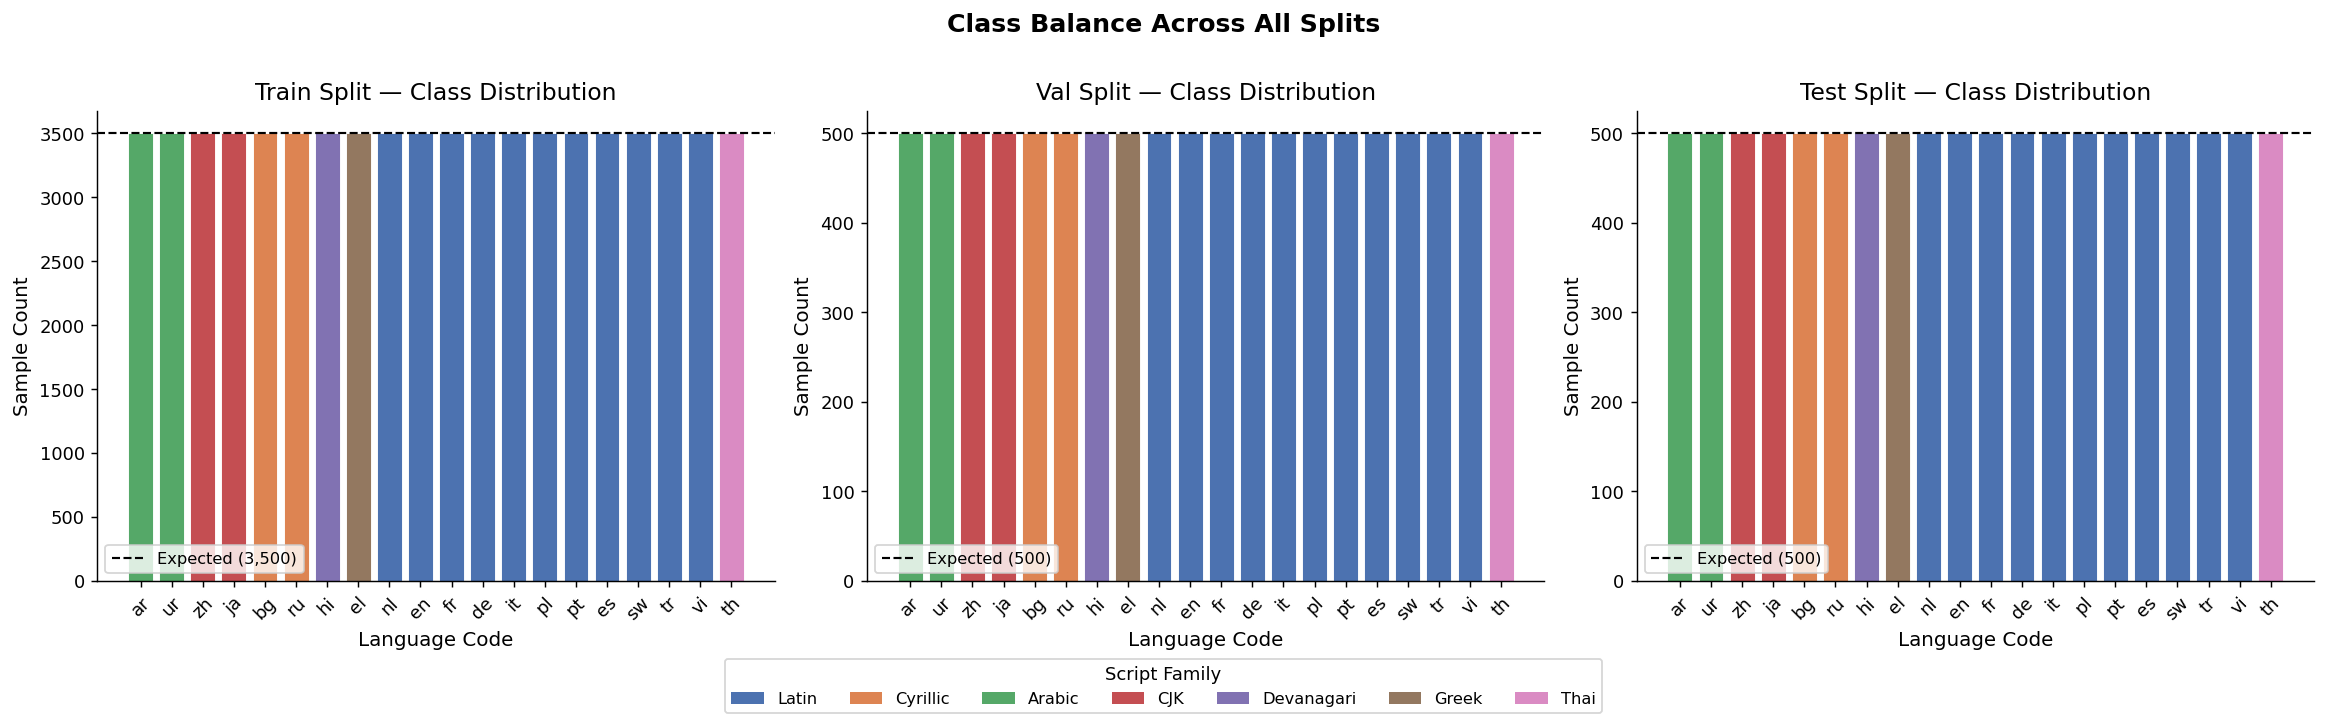

Saved: eda_01_class_balance.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize = (18, 5))
splits = [('train', train_df, 3500), ('val', val_df, 500), ('test', test_df, 500)]

for ax, (split_name, df, expected) in zip(axes, splits):
    counts = df['labels'].value_counts().reindex(LANG_ORDER)
    colors = [SCRIPT_COLORS[LANGUAGE_META[lang][1]] for lang in LANG_ORDER]
    bars = ax.bar(LANG_ORDER, counts.values, color = colors, edgecolor = 'white', linewidth = 0.5)

    ax.axhline(expected, color = 'black', linestyle = '--', linewidth = 1.2, label = f'Expected ({expected:,})')
    ax.set_title(f'{split_name.capitalize()} Split — Class Distribution')
    ax.set_xlabel('Language Code')
    ax.set_ylabel('Sample Count')
    ax.legend(fontsize = 9)
    ax.tick_params(axis = 'x', rotation = 45)

# Script legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor = color, label = script) for script, color in SCRIPT_COLORS.items()]
fig.legend(handles = legend_elements, title = 'Script Family', loc = 'lower center',
           ncol = 7, bbox_to_anchor = (0.5, -0.08), fontsize = 9)


plt.suptitle('Class Balance Across All Splits', fontsize = 14, fontweight = 'bold', y = 1.01)
plt.tight_layout()
plt.savefig('eda_01_class_balance.png', bbox_inches = 'tight')
plt.show()
print("Saved: eda_01_class_balance.png")

## 5. Question 2 (Text Length Distribution per Language)

Short texts reduce the n-gram signal significantly.  
A 3-character text has almost no discriminative character n-grams.  
We analyze both character-level and word-level length.

In [6]:
full_df['char_len']     = full_df['text'].str.len()
full_df['word_len']     = full_df['text'].str.split().str.len()
full_df['unique_chars'] = full_df['text'].apply(lambda x: len(set(x.lower())))

length_stats = (
    full_df.groupby('lang_name')[['char_len', 'word_len', 'unique_chars']]
    .agg(['mean', 'median', 'min', 'max', 'std'])
    .round(1)
)

print("Text length statistics per language (character level):")
print(length_stats['char_len'].sort_values('mean').to_string())

Text length statistics per language (character level):
             mean  median  min   max    std
lang_name                                  
Chinese      50.3    37.0   15   942   43.1
Polish       63.1    53.0   10   368   39.7
Dutch        66.5    54.0   12   414   42.2
Portuguese   66.7    55.0    8   418   39.4
Italian      69.6    57.0   11   464   41.9
Urdu         89.1    79.0    3   617   57.6
Arabic       95.9    84.0    2   625   63.1
Japanese     99.5    71.0   15  1353   94.0
Turkish     103.2    92.0    3   677   66.0
Swahili     107.2    95.0    5   715   69.5
Thai        113.0    98.0    7   876   76.3
Bulgarian   113.6   100.0    6   808   75.5
Hindi       114.0    99.0    6   876   74.8
Russian     116.3   101.0    5   814   77.9
Vietnamese  119.9   107.0    7   794   76.4
Greek       125.3   111.0    6   812   83.1
Spanish     151.6   120.0   20  1708  135.4
French      158.9   126.0   19  2422  134.3
English     179.4   126.0   20  3657  184.0
German      205.8   1

**Short text languages (mean < 100 chars)**

- Chinese (50), Polish (63), Dutch (66), Portuguese (67), Italian (70)
These are predominantly product reviews and short sentences from the dataset sources

- Chinese appears shortest because CJK characters are information-dense one character carries what Latin scripts express in 3–5 characters

**Long text languages (mean > 150 chars)**

- Spanish (152), French (159), English (179), German (206)
These tend to have longer review texts and news sentences in the dataset
German specifically is known for compound words — Lichterkette, Panzerglas — which inflate character count significantly


**Critical Observations**

1- Minimum values are alarming for some languages

- Arabic min = 2 chars, Urdu min = 3 chars, Turkish min = 3 chars
A 2-character Arabic text gives the model essentially one bigram to work with
This is where ar ↔ ur confusion will almost certainly occur not on normal texts but on these extreme edge cases

2- Standard deviation tells the real story

- English std = 184, German std = 187, French std = 134
These are enormous relative to their means meaning the distribution is heavily right-skewed with many short texts but some extremely long ones
English max = 3,657 chars nearly 4x the mean confirming heavy skew and
Chinese std = 43 is very tight distribution and consistent short texts



## **Text Length Problems & Recommended Solutions**

#### **Problem 1 (Arabic & Urdu minimum length (2–3 characters))**

- Same script with near-zero n-gram signal at extreme short lengths.

- Most dangerous case as it coincides with high-stakes crisis messages.

- Solutions:

   - Add confidence threshold at inference (distrust predictions on texts shorter than 15 characters)
   - Inherit language from conversation history when confidence is low rather than making a wrong hard decision

#### **Problem 2 (High standard deviation in English, German, French)**

- Extreme length variability causes raw term frequencies to misrepresent short samples relative to long ones model learns length patterns instead of language patterns

- Solutions:

   - sublinear_tf = True compresses term frequencies via 1 + log(tf) making short and long texts comparable in feature space


#### **Problem 3 (Short Latin-script languages (Polish, Dutch, Portuguese, Italian))**

- Mean 63–70 characters with no unique script makes the discriminative signal relies entirely on rare morphological patterns like ção, lijk , szcz Setting

- Solutions:

   - max_features = 300,000 ensures rare but highly discriminative n-grams are retained rather than cut from the vocabulary as it gives enough room to retain both the common shared n-grams AND the rare discriminative ones. The rare patterns survive the cut and the model can confidently identify Polish from Dutch from Portuguese even on short texts If we set max_features = 50,000 the vectorizer fills those 50k slots with the most common n-grams which are largely shared across languages like " th", "in ", "en ". The rare but discriminative patterns like "szcz" get cut off because they are not frequent enough to make the top 50k.

#### **Problem 4 (Ambiguous short messages at inference)**

- A user typing a single word provides insufficient signal for any model regardless of architecture this is a system design gap not a modeling gap

- Solutions:

  - Use conversation history to inherit the language established in previous turns
  - Fall back to English only when no history exists

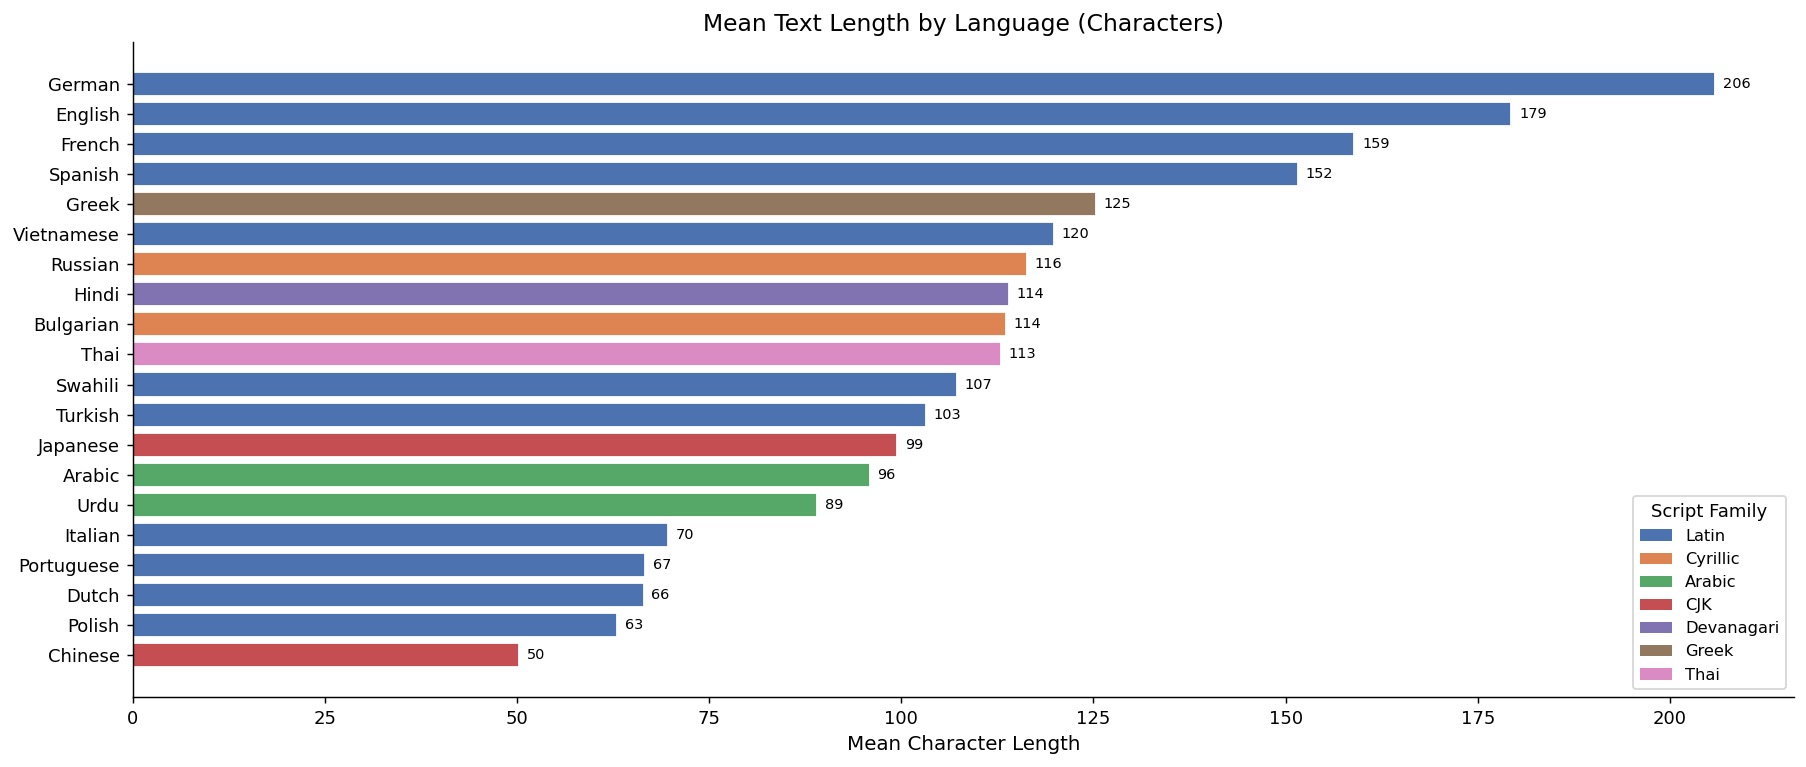

Saved: eda_02a_mean_char_length.png


In [7]:
# Mean character length per language and sorted ascending
mean_char = full_df.groupby(['language', 'lang_name', 'script'])['char_len'].mean().reset_index()
mean_char = mean_char.sort_values('char_len')
bar_colors = [SCRIPT_COLORS[s] for s in mean_char['script']]

fig, ax = plt.subplots(figsize = (14, 6))
ax.barh(mean_char['lang_name'], mean_char['char_len'], color = bar_colors, edgecolor = 'white')
ax.set_xlabel('Mean Character Length')
ax.set_title('Mean Text Length by Language (Characters)')

for i, (_, row) in enumerate(mean_char.iterrows()):
    ax.text(row['char_len'] + 1, i, f"{row['char_len']:.0f}", va = 'center', fontsize = 8)

legend_elements = [Patch(facecolor = color, label = script) for script, color in SCRIPT_COLORS.items()]
ax.legend(handles = legend_elements, title = 'Script Family', loc = 'lower right', fontsize = 9)

plt.tight_layout()
plt.savefig('eda_02a_mean_char_length.png', bbox_inches = 'tight')
plt.show()
print("Saved: eda_02a_mean_char_length.png")

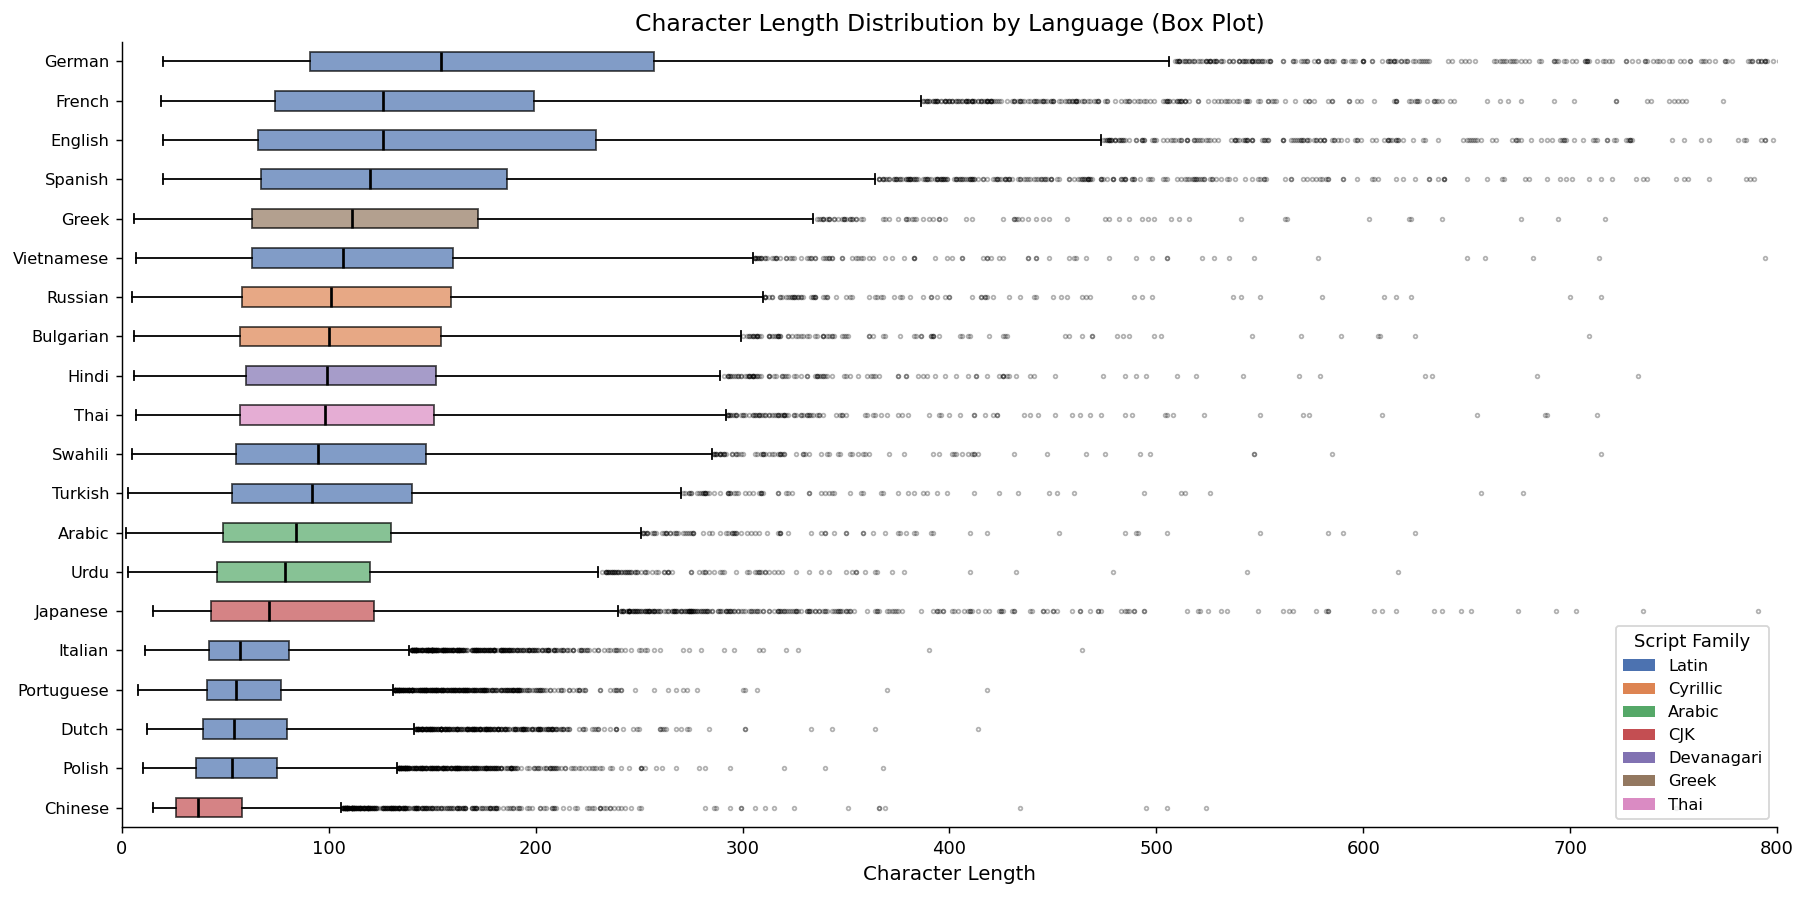

Saved: eda_02b_boxplot_char_length.png


In [8]:
# Character length distribution per language sorted by median
lang_order_by_median = (
    full_df.groupby('lang_name')['char_len'].median()
    .sort_values().index.tolist()
)
plot_data      = [full_df[full_df['lang_name'] == lang]['char_len'].values for lang in lang_order_by_median]
script_for_order = [full_df[full_df['lang_name'] == lang]['script'].iloc[0] for lang in lang_order_by_median]
bp_colors      = [SCRIPT_COLORS[s] for s in script_for_order]

fig, ax = plt.subplots(figsize = (14, 7))

bp = ax.boxplot(plot_data, vert       = False,
                            patch_artist = True,
                            flierprops   = dict(marker = 'o', markersize = 2, alpha = 0.3),
                            medianprops  = dict(color = 'black', linewidth = 1.5))

for patch, color in zip(bp['boxes'], bp_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_yticks(range(1, len(lang_order_by_median) + 1))
ax.set_yticklabels(lang_order_by_median, fontsize = 9)
ax.set_xlabel('Character Length')
ax.set_title('Character Length Distribution by Language (Box Plot)')
ax.set_xlim(0, 800)

legend_elements = [Patch(facecolor = color, label = script) for script, color in SCRIPT_COLORS.items()]
ax.legend(handles = legend_elements, title = 'Script Family', loc = 'lower right', fontsize = 9)

plt.tight_layout()
plt.savefig('eda_02b_boxplot_char_length.png', bbox_inches = 'tight')
plt.show()
print("Saved: eda_02b_boxplot_char_length.png")

## **Box Plot Insights**

**German, French, English, Spanish are the widest boxes**

- Largest IQR meaning highly variable text lengths as these languages have both very short and very long samples confirming the high std we saw in the statistics.

**Chinese and Polish have the tightest boxes**

- Most consistent text lengths across samples the model sees very uniform feature vector sizes for these languages which is actually helpful for stable training.

**Almost every language has extreme outliers stretching to 600–800+ chars**

- The dots far to the right are long product reviews and news articles these are not noise they are legitimate samples but they confirm sublinear_tf = True is non-negotiable to prevent long texts from dominating.

**Arabic and Urdu boxes start very close to zero**

- Their left whisker nearly touches the y-axis confirming the minimum 2–3 character samples we found earlier and these are the dangerous edge cases at inference time.

**Japanese box is wide despite CJK script**
- High variance compared to Chinese as Japanese mixes three writing systems (Hiragana, Katakana, Kanji) which produces more variable text lengths than pure Chinese characters.

**Latin-script languages cluster in the 50–300 char range as a group**

- No single Latin language is dramatically longer or shorter than its neighbors meaning the model cannot use length as a signal to separate them it must rely entirely on character patterns.

In [9]:
# Identify very short texts that may cause misclassification
SHORT_THRESHOLD = 20  # characters

short_texts = full_df[full_df['char_len'] <= SHORT_THRESHOLD]
short_by_lang = short_texts.groupby('lang_name').size().sort_values(ascending = False)

print(f"Texts with <= {SHORT_THRESHOLD} characters: {len(short_texts):,} ({len(short_texts)/len(full_df)*100:.2f}% of dataset)")
print("\nShort text count per language:")
print(short_by_lang.to_string())

Texts with <= 20 characters: 2,284 (2.54% of dataset)

Short text count per language:
lang_name
Urdu          268
Arabic        233
Chinese       209
Swahili       200
Turkish       191
Bulgarian     157
Russian       153
Greek         146
Thai          145
Polish        140
Hindi         124
Vietnamese     90
Dutch          54
Japanese       47
Italian        30
English        27
Portuguese     27
French         20
Spanish        17
German          6


In [10]:
print("\nSample short texts:")
print(short_texts[['lang_name', 'text', 'char_len']].head(20).to_string(index = False))


Sample short texts:
lang_name                 text  char_len
  Russian    Больно ходить . "        17
    Hindi    यह अलग हो जाएगा .        17
     Thai  โอ้ ใช่ คุณ คิด ว่า        19
  Russian Я не верю в пенсию .        20
  Chinese 太慢了 我已经买了好多天了 还没到 无语        20
    Greek       - Δύο χρόνια .        14
   Arabic       من غير المحتمل        14
    Greek Τι σου έλεγα πάντα ;        20
    Hindi    फिर भी , ऐ राजा !        17
   Polish        Droższe domy.        13
   French Arnaque ! Très déçue        20
  Turkish      Teşekkür ederim        15
     Urdu  آپ کیا کر رہے ہیں ؟        19
  Russian       Он так устал .        14
 Japanese 迅速なので何回もお世話になっております。        20
  Russian          Он дрожал .        11
     Thai      เอิ่มมมมมมมมมมม        15
     Thai      น่าสนใจ มาก ค่ะ        15
     Urdu               وولف .         6
    Greek        Δοκίμασέ με .        13


## 6. Question 3 (Script Distribution & Trivially Separable Languages)

Languages with unique scripts are essentially solved by a single character lookup.  
The real modeling challenge lives entirely within the Latin-script group.

In [11]:
script_summary = (
    full_df.groupby('script')['language']
    .apply(lambda x: sorted(x.unique().tolist()))
    .reset_index()
)
script_summary['count']     = script_summary['language'].apply(len)
script_summary['languages'] = script_summary['language'].apply(
    lambda codes: ', '.join([f"{c} ({LANGUAGE_META[c][0]})" for c in codes])
)

display(
    script_summary[['script', 'count', 'languages']]
    .sort_values('count', ascending = False)
    .reset_index(drop = True)
    .style
    .set_caption("Script Family Breakdown")
    .set_properties(**{'text-align': 'left'})
)

,script,count,languages
0,Latin,11,"de (German), en (English), es (Spanish), fr (French), it (Italian), nl (Dutch), pl (Polish), pt (Portuguese), sw (Swahili), tr (Turkish), vi (Vietnamese)"
1,CJK,2,"ja (Japanese), zh (Chinese)"
2,Arabic,2,"ar (Arabic), ur (Urdu)"
3,Cyrillic,2,"bg (Bulgarian), ru (Russian)"
4,Devanagari,1,hi (Hindi)
5,Greek,1,el (Greek)
6,Thai,1,th (Thai)


In [12]:
latin_langs         = [code for code, (_, script) in LANGUAGE_META.items() if script == 'Latin']
unique_script_langs = [code for code, (_, script) in LANGUAGE_META.items() if script != 'Latin']

# Scripts that appear more than once — shared within non-Latin group
script_counts       = Counter(script for _, (_, script) in LANGUAGE_META.items())
shared_scripts      = {script for script, count in script_counts.items() if count > 1 and script != 'Latin'}
truly_unique_langs  = [code for code, (_, script) in LANGUAGE_META.items() if script not in shared_scripts and script != 'Latin']
shared_script_langs = [code for code, (_, script) in LANGUAGE_META.items() if script in shared_scripts]

print(f"Truly unique-script languages ({len(truly_unique_langs)}) (trivially separable near 100% expected):")
for code in truly_unique_langs:
    name, script = LANGUAGE_META[code]
    print(f"  [{code}] {name:<12} — {script} script")


print(f"\nShared non-Latin script languages ({len(shared_script_langs)}) (hard pairs despite unique script):")
for code in shared_script_langs:
    name, script = LANGUAGE_META[code]
    print(f"  [{code}] {name:<12} — {script} script")


print(f"\nLatin-script languages ({len(latin_langs)}) (hardest group as model must rely entirely on morphology):")
for code in sorted(latin_langs):
    name, script = LANGUAGE_META[code]
    print(f"  [{code}] {name:<12} — {script} script")

Truly unique-script languages (3) (trivially separable near 100% expected):
  [el] Greek        — Greek script
  [hi] Hindi        — Devanagari script
  [th] Thai         — Thai script

Shared non-Latin script languages (6) (hard pairs despite unique script):
  [ar] Arabic       — Arabic script
  [bg] Bulgarian    — Cyrillic script
  [ja] Japanese     — CJK script
  [ru] Russian      — Cyrillic script
  [ur] Urdu         — Arabic script
  [zh] Chinese      — CJK script

Latin-script languages (11) (hardest group as model must rely entirely on morphology):
  [de] German       — Latin script
  [en] English      — Latin script
  [es] Spanish      — Latin script
  [fr] French       — Latin script
  [it] Italian      — Latin script
  [nl] Dutch        — Latin script
  [pl] Polish       — Latin script
  [pt] Portuguese   — Latin script
  [sw] Swahili      — Latin script
  [tr] Turkish      — Latin script
  [vi] Vietnamese   — Latin script


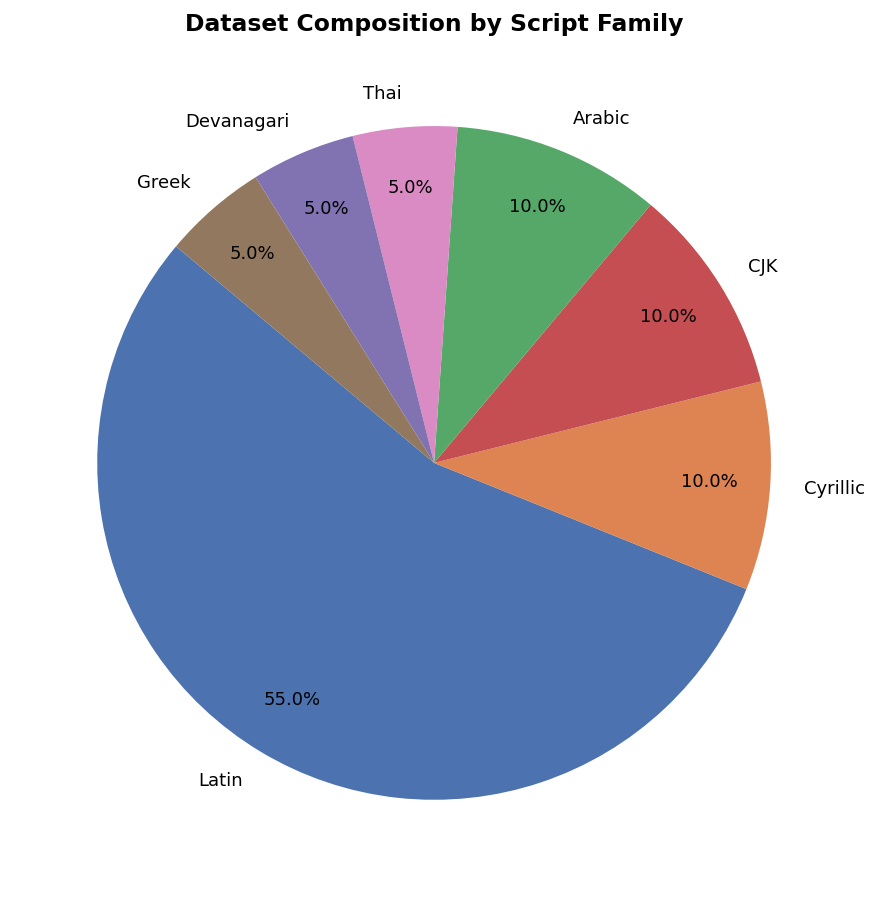

Saved: eda_03a_script_pie.png


In [13]:
# Dataset composition by script family
script_counts = full_df['script'].value_counts()
fig, ax = plt.subplots(figsize = (7, 7))

ax.pie(
    script_counts.values,
    labels     = script_counts.index,
    colors     = [SCRIPT_COLORS[s] for s in script_counts.index],
    autopct    = '%1.1f%%',
    startangle = 140,
    pctdistance = 0.82,
    textprops  = {'fontsize': 10}
)
ax.set_title('Dataset Composition by Script Family', fontsize = 13, fontweight = 'bold')

plt.tight_layout()
plt.savefig('eda_03a_script_pie.png', bbox_inches = 'tight')
plt.show()
print("Saved: eda_03a_script_pie.png")

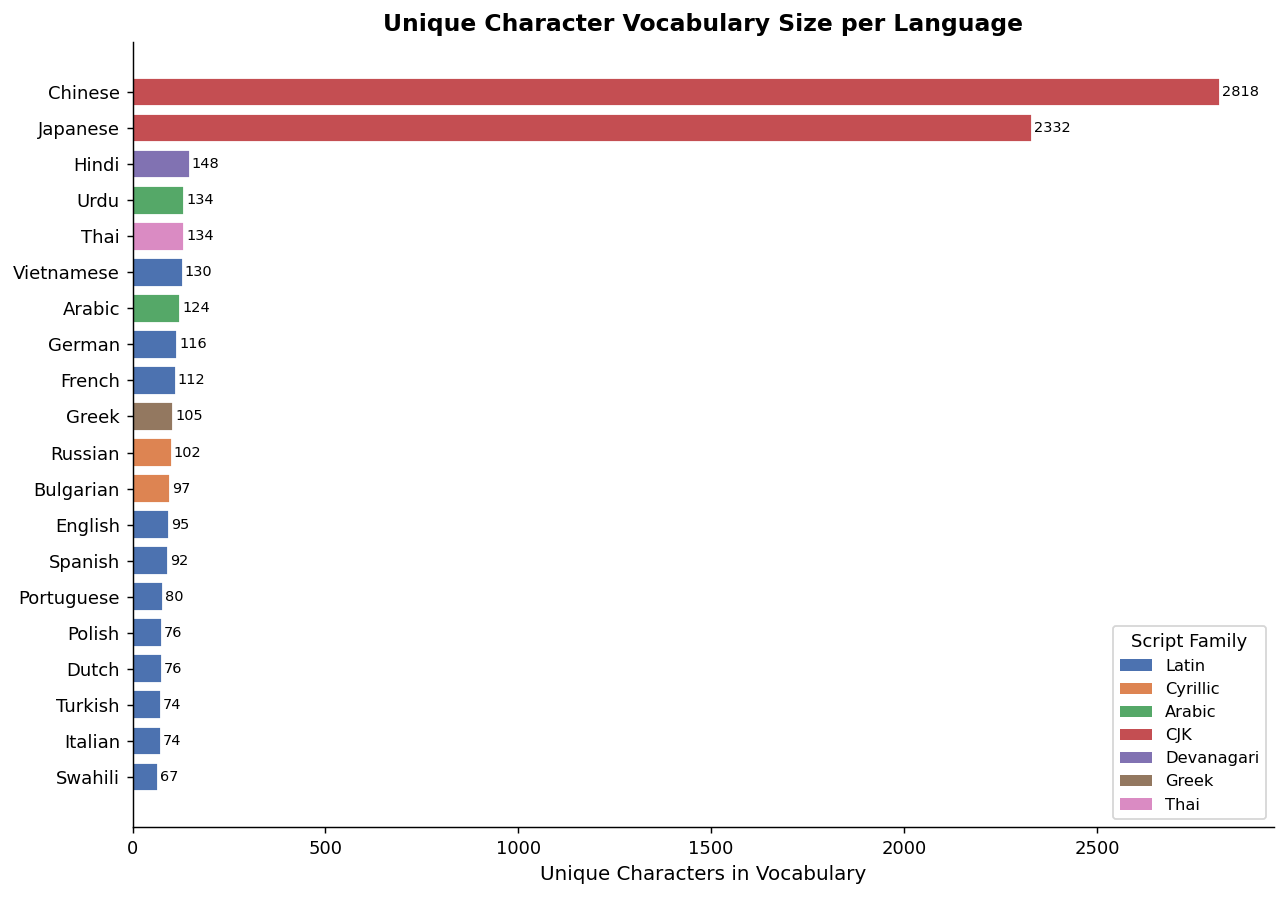

Saved: eda_03b_vocab_size.png


In [14]:
# Unique character vocabulary size per language
vocab_data = (
    full_df.groupby(['lang_name', 'script'])['text']
    .apply(lambda texts: len(set(''.join(texts).lower())))   # Takes all text samples for one language and concatenates them into a single giant string  and Converts everything to lowercase so 'A' and 'a' are not counted as two different characters.
    .reset_index(name = 'unique_chars_vocab')
    .sort_values('unique_chars_vocab', ascending = True)
)
v_colors = [SCRIPT_COLORS[s] for s in vocab_data['script']]


fig, ax = plt.subplots(figsize = (10, 7))
ax.barh(vocab_data['lang_name'], vocab_data['unique_chars_vocab'], color = v_colors, edgecolor = 'white')
ax.set_xlabel('Unique Characters in Vocabulary')
ax.set_title('Unique Character Vocabulary Size per Language', fontsize = 13, fontweight = 'bold')

for i, (_, row) in enumerate(vocab_data.iterrows()):
    ax.text(row['unique_chars_vocab'] + 5, i, str(row['unique_chars_vocab']), va = 'center', fontsize = 8)

legend_elements = [Patch(facecolor = color, label = script) for script, color in SCRIPT_COLORS.items()]
ax.legend(handles = legend_elements, title = 'Script Family', loc = 'lower right', fontsize = 9)

plt.tight_layout()
plt.savefig('eda_03b_vocab_size.png', bbox_inches = 'tight')
plt.show()
print("Saved: eda_03b_vocab_size.png")

**CJK (Chinese 2818, Japanese 2332) Trivially Separable**

Thousands of unique characters means a single character from a Chinese text has almost zero probability of appearing in any other language in the dataset. The model does not need n-grams, morphology or any learned pattern  character identity alone is a near-certain signal. Additionally Chinese and Japanese are separable from each other because Japanese mixes Hiragana and Katakana characters alongside Kanji while Chinese uses only Hanzi, making their character distributions statistically distinct even though they share some CJK codepoints.

---

**Non-Latin Scripts (Hindi 148, Urdu 134, Thai 134, Arabic 124) Separable by Script Identity**

Each of these languages uses a script that no other language in the dataset shares exclusively except Arabic and Urdu which share the same script. For Hindi, Thai and Greek, seeing even one character from their alphabet instantly identifies the language with near-certainty because those characters simply do not appear in any other language's text. Arabic and Urdu are the exception both use Arabic script with similar character counts of 124 and 134, meaning script identity alone is insufficient for this pair and the model must fall back on character combination frequencies and morphological n-gram patterns specific to each language's grammar.

---

**Latin Scripts (Swahili 67 → German 116) N-gram Patterns Are the Only Signal**

All 11 Latin-script languages share the same basic alphabet of ~26 letters. The difference between 67 unique characters in Swahili and 116 in German comes entirely from diacritics German adds `ä ö ü ß`, French adds `é à ù ê ç`, Portuguese adds `ã õ ç`. These diacritics are the first line of discrimination and this is precisely why `strip_accents=None` is non-negotiable in our vectorizer. However diacritics alone are not enough  English and Swahili both sit below 100 unique chars with minimal diacritics yet they must still be separated. This is where character n-grams (2–4) become the sole discriminative mechanism capturing morphological fingerprints like `lijk` for Dutch, `szcz` for Polish, `ção` for Portuguese that are statistically unique to each language even though they are built from the same base alphabet.

## 7. Question 4 (Hard Pairs: Character N-gram Overlap Between Latin Languages)

We compute pairwise TF-IDF cosine similarity across language centroids.  
A high cosine similarity between two language centroids = they share a lot of character n-gram signal = higher confusion risk.  
This directly tells us where our classifier will struggle.

In [15]:
# Build one representative document per language from training data only to avoid data leakage in analysis
train_df_copy = train_df.copy()
train_df_copy['lang_name'] = train_df_copy['labels'].map(lambda x: LANGUAGE_META[x][0])
lang_corpora = (
    train_df_copy.groupby('labels')['text']
    .apply(lambda texts: ' '.join(texts.tolist()))
    .to_dict()
)



# char_wb n-grams (same config we will use in the model)
tfidf_overlap = TfidfVectorizer(
    analyzer     = 'char_wb',
    ngram_range  = (2, 4),
    max_features = 300_000,  # increased to retain rare discriminative patterns
    sublinear_tf = True,
    strip_accents = None     # never strip as diacritics are features
)

lang_codes_sorted = sorted(lang_corpora.keys())
corpus_list       = [lang_corpora[lang] for lang in lang_codes_sorted]
lang_vectors      = tfidf_overlap.fit_transform(corpus_list)
similarity_matrix = cosine_similarity(lang_vectors)

sim_df = pd.DataFrame(
    similarity_matrix,
    index   = [LANGUAGE_META[l][0] for l in lang_codes_sorted],
    columns = [LANGUAGE_META[l][0] for l in lang_codes_sorted]
)

print("Language centroid cosine similarity matrix (char 2-4 grams):")
print(sim_df.round(3).to_string())

Language centroid cosine similarity matrix (char 2-4 grams):
            Arabic  Bulgarian  German  Greek  English  Spanish  French  Hindi  Italian  Japanese  Dutch  Polish  Portuguese  Russian  Swahili   Thai  Turkish   Urdu  Vietnamese  Chinese
Arabic       1.000      0.012   0.021  0.012    0.028    0.023   0.022  0.015    0.031     0.002  0.026   0.018       0.026    0.011    0.037  0.014    0.027  0.261       0.023    0.002
Bulgarian    0.012      1.000   0.021  0.013    0.029    0.024   0.023  0.015    0.032     0.002  0.027   0.019       0.027    0.653    0.037  0.014    0.028  0.009       0.023    0.002
German       0.021      0.021   1.000  0.026    0.315    0.206   0.219  0.039    0.231     0.010  0.330   0.160       0.197    0.019    0.210  0.041    0.179  0.021       0.079    0.008
Greek        0.012      0.013   0.026  1.000    0.036    0.030   0.028  0.016    0.040     0.002  0.034   0.023       0.034    0.011    0.046  0.017    0.034  0.009       0.028    0.002
English  

In [16]:
# Top 15 most similar (most confusable) language pairs
pair_similarities = []
lang_names_sorted = [LANGUAGE_META[l][0] for l in lang_codes_sorted]

for i, j in combinations(range(len(lang_names_sorted)), 2):
    lang_a = lang_names_sorted[i]
    lang_b = lang_names_sorted[j]
    sim = similarity_matrix[i, j]
    script_a = LANGUAGE_META[lang_codes_sorted[i]][1]
    script_b = LANGUAGE_META[lang_codes_sorted[j]][1]
    same_script = script_a == script_b
    pair_similarities.append({
        'lang_a': lang_a, 'lang_b': lang_b,
        'similarity': sim,
        'same_script': same_script,
        'scripts': f"{script_a} / {script_b}"
    })


pair_df = pd.DataFrame(pair_similarities).sort_values('similarity', ascending = False)
print("Top 20 most confusable language pairs (highest char n-gram overlap):")
print(pair_df.head(20).to_string(index=False))


print("\nTop 10 DIFFERENT-script pairs with high similarity (unexpected confusion risks):")
print(pair_df[~pair_df['same_script']].head(10).to_string(index=False))

Top 20 most confusable language pairs (highest char n-gram overlap):
   lang_a     lang_b  similarity  same_script             scripts
Bulgarian    Russian    0.653162         True Cyrillic / Cyrillic
  Italian Portuguese    0.467122         True       Latin / Latin
  Spanish Portuguese    0.444397         True       Latin / Latin
  Italian      Dutch    0.376697         True       Latin / Latin
  Spanish    Italian    0.359950         True       Latin / Latin
  English      Dutch    0.342942         True       Latin / Latin
  English    Italian    0.340383         True       Latin / Latin
  English    Swahili    0.337387         True       Latin / Latin
   German      Dutch    0.330186         True       Latin / Latin
  English     French    0.327741         True       Latin / Latin
    Dutch Portuguese    0.322165         True       Latin / Latin
   German    English    0.314551         True       Latin / Latin
   French    Italian    0.308567         True       Latin / Latin
  Itali

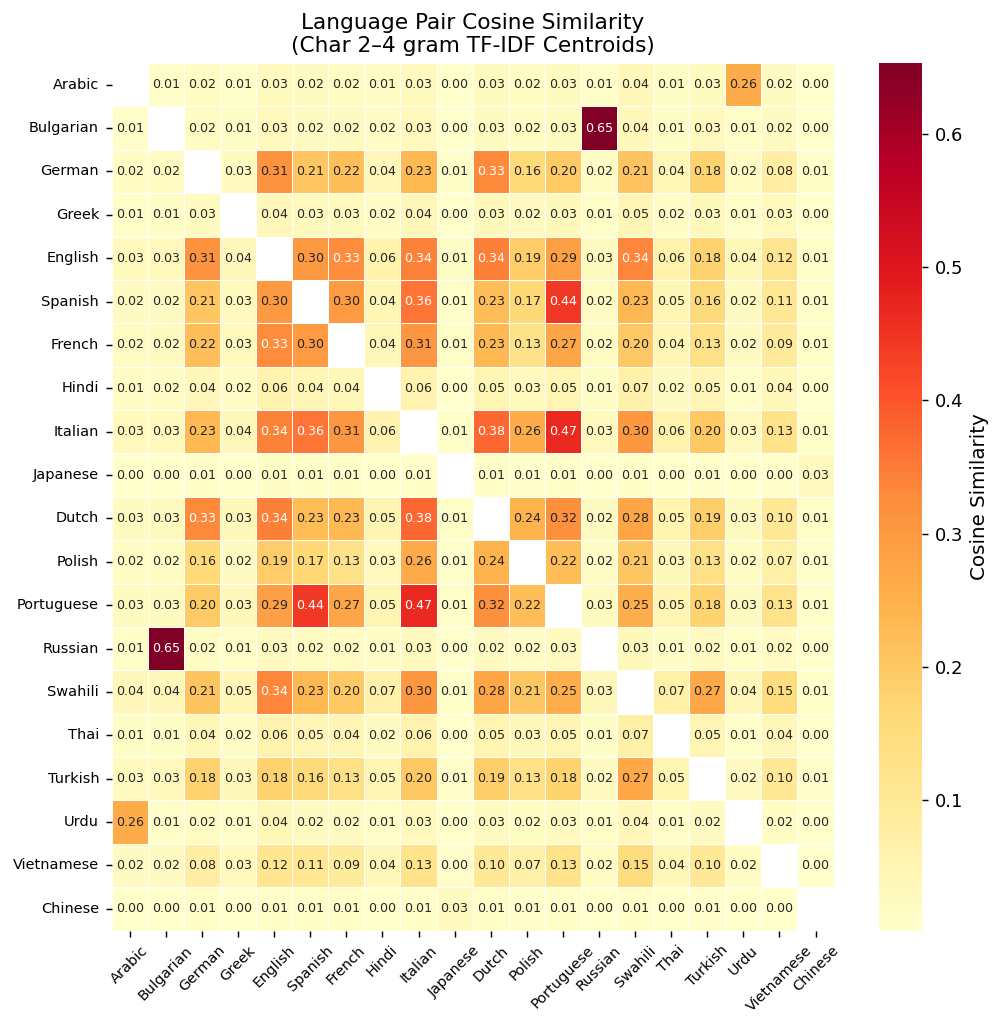

Saved: eda_04_similarity_heatmap.png


In [17]:
# Full similarity heatmap
fig, ax = plt.subplots(figsize = (8, 8))
mask = np.eye(len(sim_df), dtype = bool)  # mask diagonal (self-similarity = 1.0)

sns.heatmap(
    sim_df,
    ax    = ax,
    annot = True,
    fmt   = '.2f',
    cmap  = 'YlOrRd',
    mask  = mask,
    linewidths = 0.5,
    linecolor  = 'white',
    annot_kws  = {'size': 7},
    cbar_kws   = {'label': 'Cosine Similarity'}
)

ax.set_title(
    'Language Pair Cosine Similarity\n(Char 2–4 gram TF-IDF Centroids)',
    fontsize = 12
)

ax.tick_params(axis = 'x', rotation = 45, labelsize = 8)
ax.tick_params(axis = 'y', rotation = 0, labelsize = 8)
plt.tight_layout()
plt.savefig('eda_04_similarity_heatmap.png', bbox_inches = 'tight')
plt.show()
print("Saved: eda_04_similarity_heatmap.png")

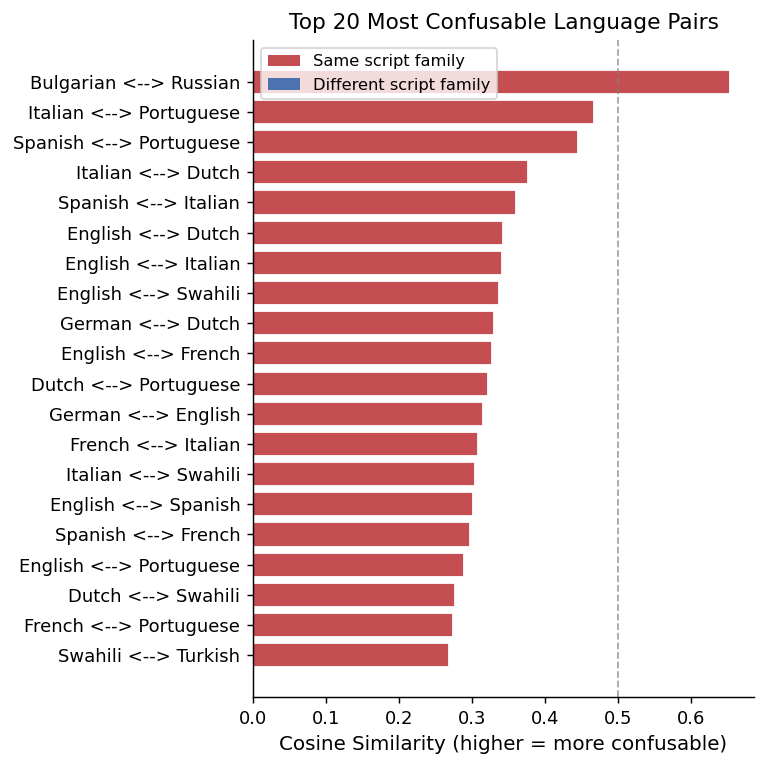

Saved: eda_04_hard_pairs.png


In [18]:
# Top 20 hardest pairs bar chart
fig, ax = plt.subplots(figsize = (6, 6))

top_pairs = pair_df.head(20).copy()
top_pairs['pair_label'] = top_pairs['lang_a'] + ' <--> ' + top_pairs['lang_b']

bar_colors_pairs = ['#C44E52' if ss else '#4C72B0' for ss in top_pairs['same_script']]

ax.barh(
    top_pairs['pair_label'][::-1],
    top_pairs['similarity'][::-1],
    color = bar_colors_pairs[::-1],
    edgecolor = 'white'
)

ax.set_xlabel('Cosine Similarity (higher = more confusable)')
ax.set_title('Top 20 Most Confusable Language Pairs', fontsize = 12)

ax.axvline(
    0.5,
    color = 'gray',
    linestyle = '--',
    linewidth = 1,
    alpha = 0.7,
    label = '0.5 threshold'
)

from matplotlib.patches import Patch as MPatch

pair_legend = [
    MPatch(facecolor = '#C44E52', label = 'Same script family'),
    MPatch(facecolor = '#4C72B0', label = 'Different script family')
]

ax.legend(handles = pair_legend, fontsize = 9)

plt.tight_layout()
plt.savefig('eda_04_hard_pairs.png', bbox_inches = 'tight')
plt.show()

print("Saved: eda_04_hard_pairs.png")

## 8. Deep Dive (Latin Script Languages Only)

Since non-Latin languages are trivially separated we focus the hard-pair analysis
specifically on Latin-script languages where the model must do real work.

In [19]:
latin_codes   = [code for code, (_, script) in LANGUAGE_META.items() if script == 'Latin']
latin_indices = [lang_codes_sorted.index(c) for c in sorted(latin_codes)]
latin_names   = [LANGUAGE_META[c][0] for c in sorted(latin_codes)]
latin_sim_matrix = similarity_matrix[np.ix_(latin_indices, latin_indices)]
latin_sim_df = pd.DataFrame(latin_sim_matrix, index=latin_names, columns=latin_names)

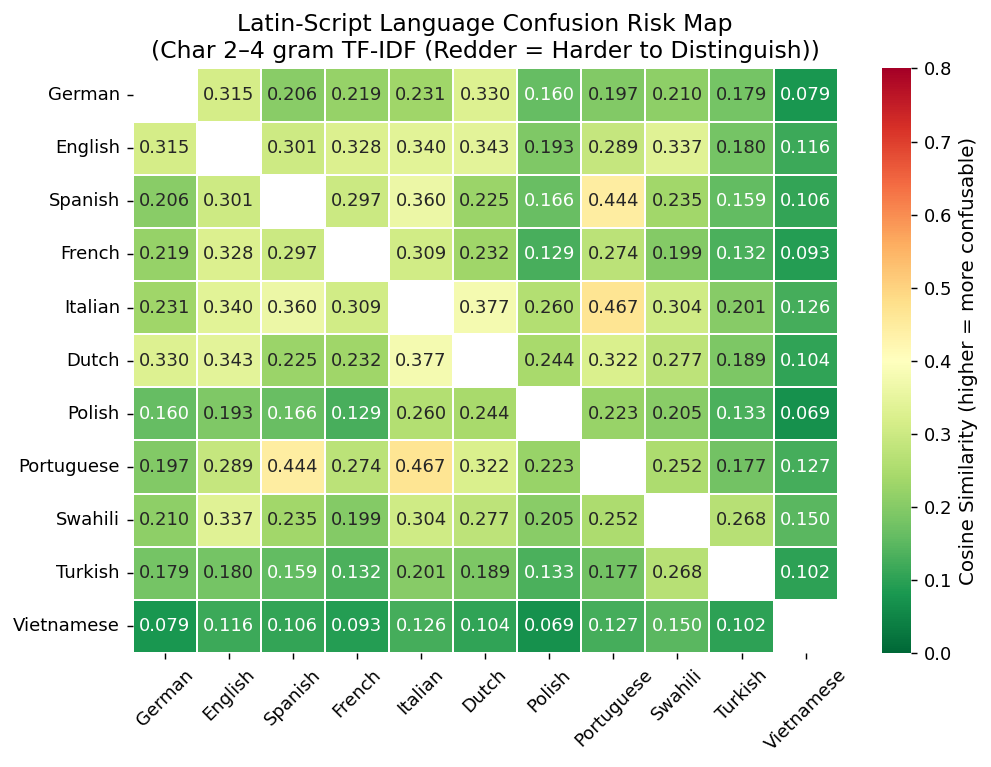

Saved: eda_05_latin_hard_pairs.png


In [20]:
fig, ax = plt.subplots(figsize = (8, 6))
mask_diag = np.eye(len(latin_sim_df), dtype = bool)
sns.heatmap(
    latin_sim_df,
    ax  = ax,
    annot = True,
    fmt = '.3f',
    cmap = 'RdYlGn_r',
    mask = mask_diag,
    linewidths = 1,
    linecolor = 'white',
    annot_kws = {'size': 10},
    vmin = 0,
    vmax = 0.8,
    cbar_kws = {'label': 'Cosine Similarity (higher = more confusable)'}
)
ax.set_title(
    'Latin-Script Language Confusion Risk Map\n'
    '(Char 2–4 gram TF-IDF (Redder = Harder to Distinguish))',
    fontsize = 13
)
ax.tick_params(axis = 'x', rotation = 45)
ax.tick_params(axis = 'y', rotation = 0)
plt.tight_layout()
plt.savefig('eda_05_latin_hard_pairs.png', bbox_inches = 'tight')
plt.show()
print("Saved: eda_05_latin_hard_pairs.png")

## 9. Top Discriminative N-grams per Language

The highest TF-IDF weight n-grams for each language reveal the actual character patterns
the model will use. This validates our feature choice and exposes what makes each
language uniquely identifiable.

In [21]:
# Refit vectorizer on all languages to get per-language top features
feature_names = tfidf_overlap.get_feature_names_out()
print("Top 10 most discriminative character n-grams per language:\n")

for i, code in enumerate(lang_codes_sorted):
    lang_name = LANGUAGE_META[code][0]
    script    = LANGUAGE_META[code][1]
    scores = lang_vectors[i].toarray().flatten()
    ranked_idx = scores.argsort()[::-1]
    selected = []

    for idx in ranked_idx:
        gram = feature_names[idx]

        if any(gram in g or g in gram for g in selected):    # Skip redundant overlapping n-grams
            continue

        selected.append(gram)
        if len(selected) == 20:
            break

    top_ngrams = [repr(g) for g in selected]

    print(f"  [{code}] {lang_name:<12} ({script:<10}): {', '.join(top_ngrams)}")

Top 10 most discriminative character n-grams per language:

  [ar] Arabic       (Arabic    ): ' ا', 'ال', 'في', 'ن ', 'ة ', ' ي', 'ية', 'ا ', 'لى', ' م', 'ي ', 'ان', 'لك', ' و', 'ها', 'ك ', 'لا', 'ل ', ' ل', 'لم'
  [bg] Bulgarian    (Cyrillic  ): 'а ', 'е ', 'и ', 'на', 'о ', ' н', ' с', ' п', 'то', ' д', ' и', 'ни', 'ра', 'та', 'ат', 'те', 'т ', ' к', 'ст', ' в'
  [de] German       (Latin     ): 'ehr ', 'sehr', ' zu ', ' auf', ' für', 'cht ', 'ät', ' ich', 'tä', 'hö', 'schl', 'gut ', 'hä', ' seh', 'eht', 'mehr', 'schn', 'lä', 'icht', 'ße'
  [el] Greek        (Greek     ): 'α ', 'ς ', ' τ', 'ι ', 'ν ', 'το', 'ου', ' π', 'ο ', ' α', ' κ', 'να', 'αι', ' ε', ' σ', ' μ', 'κα', 'τα', 'τη', 'πο'
  [en] English      (Latin     ): "n't", '’t', " i'", "it'", "'t ", ' it.', 'wou', 'purc', "sn'", 'thes', "dn'", "don'", "i'm", 'they', ' it ', 'it’', 'n’', 'only', 'i’', 'owev'
  [es] Spanish      (Latin     ): 'muy ', 'ión', 'más', ' muy', 'ño', 'pue', 'añ', 'hace', 'eñ', 'ón ', 'ría ', 'ña', 'ció'

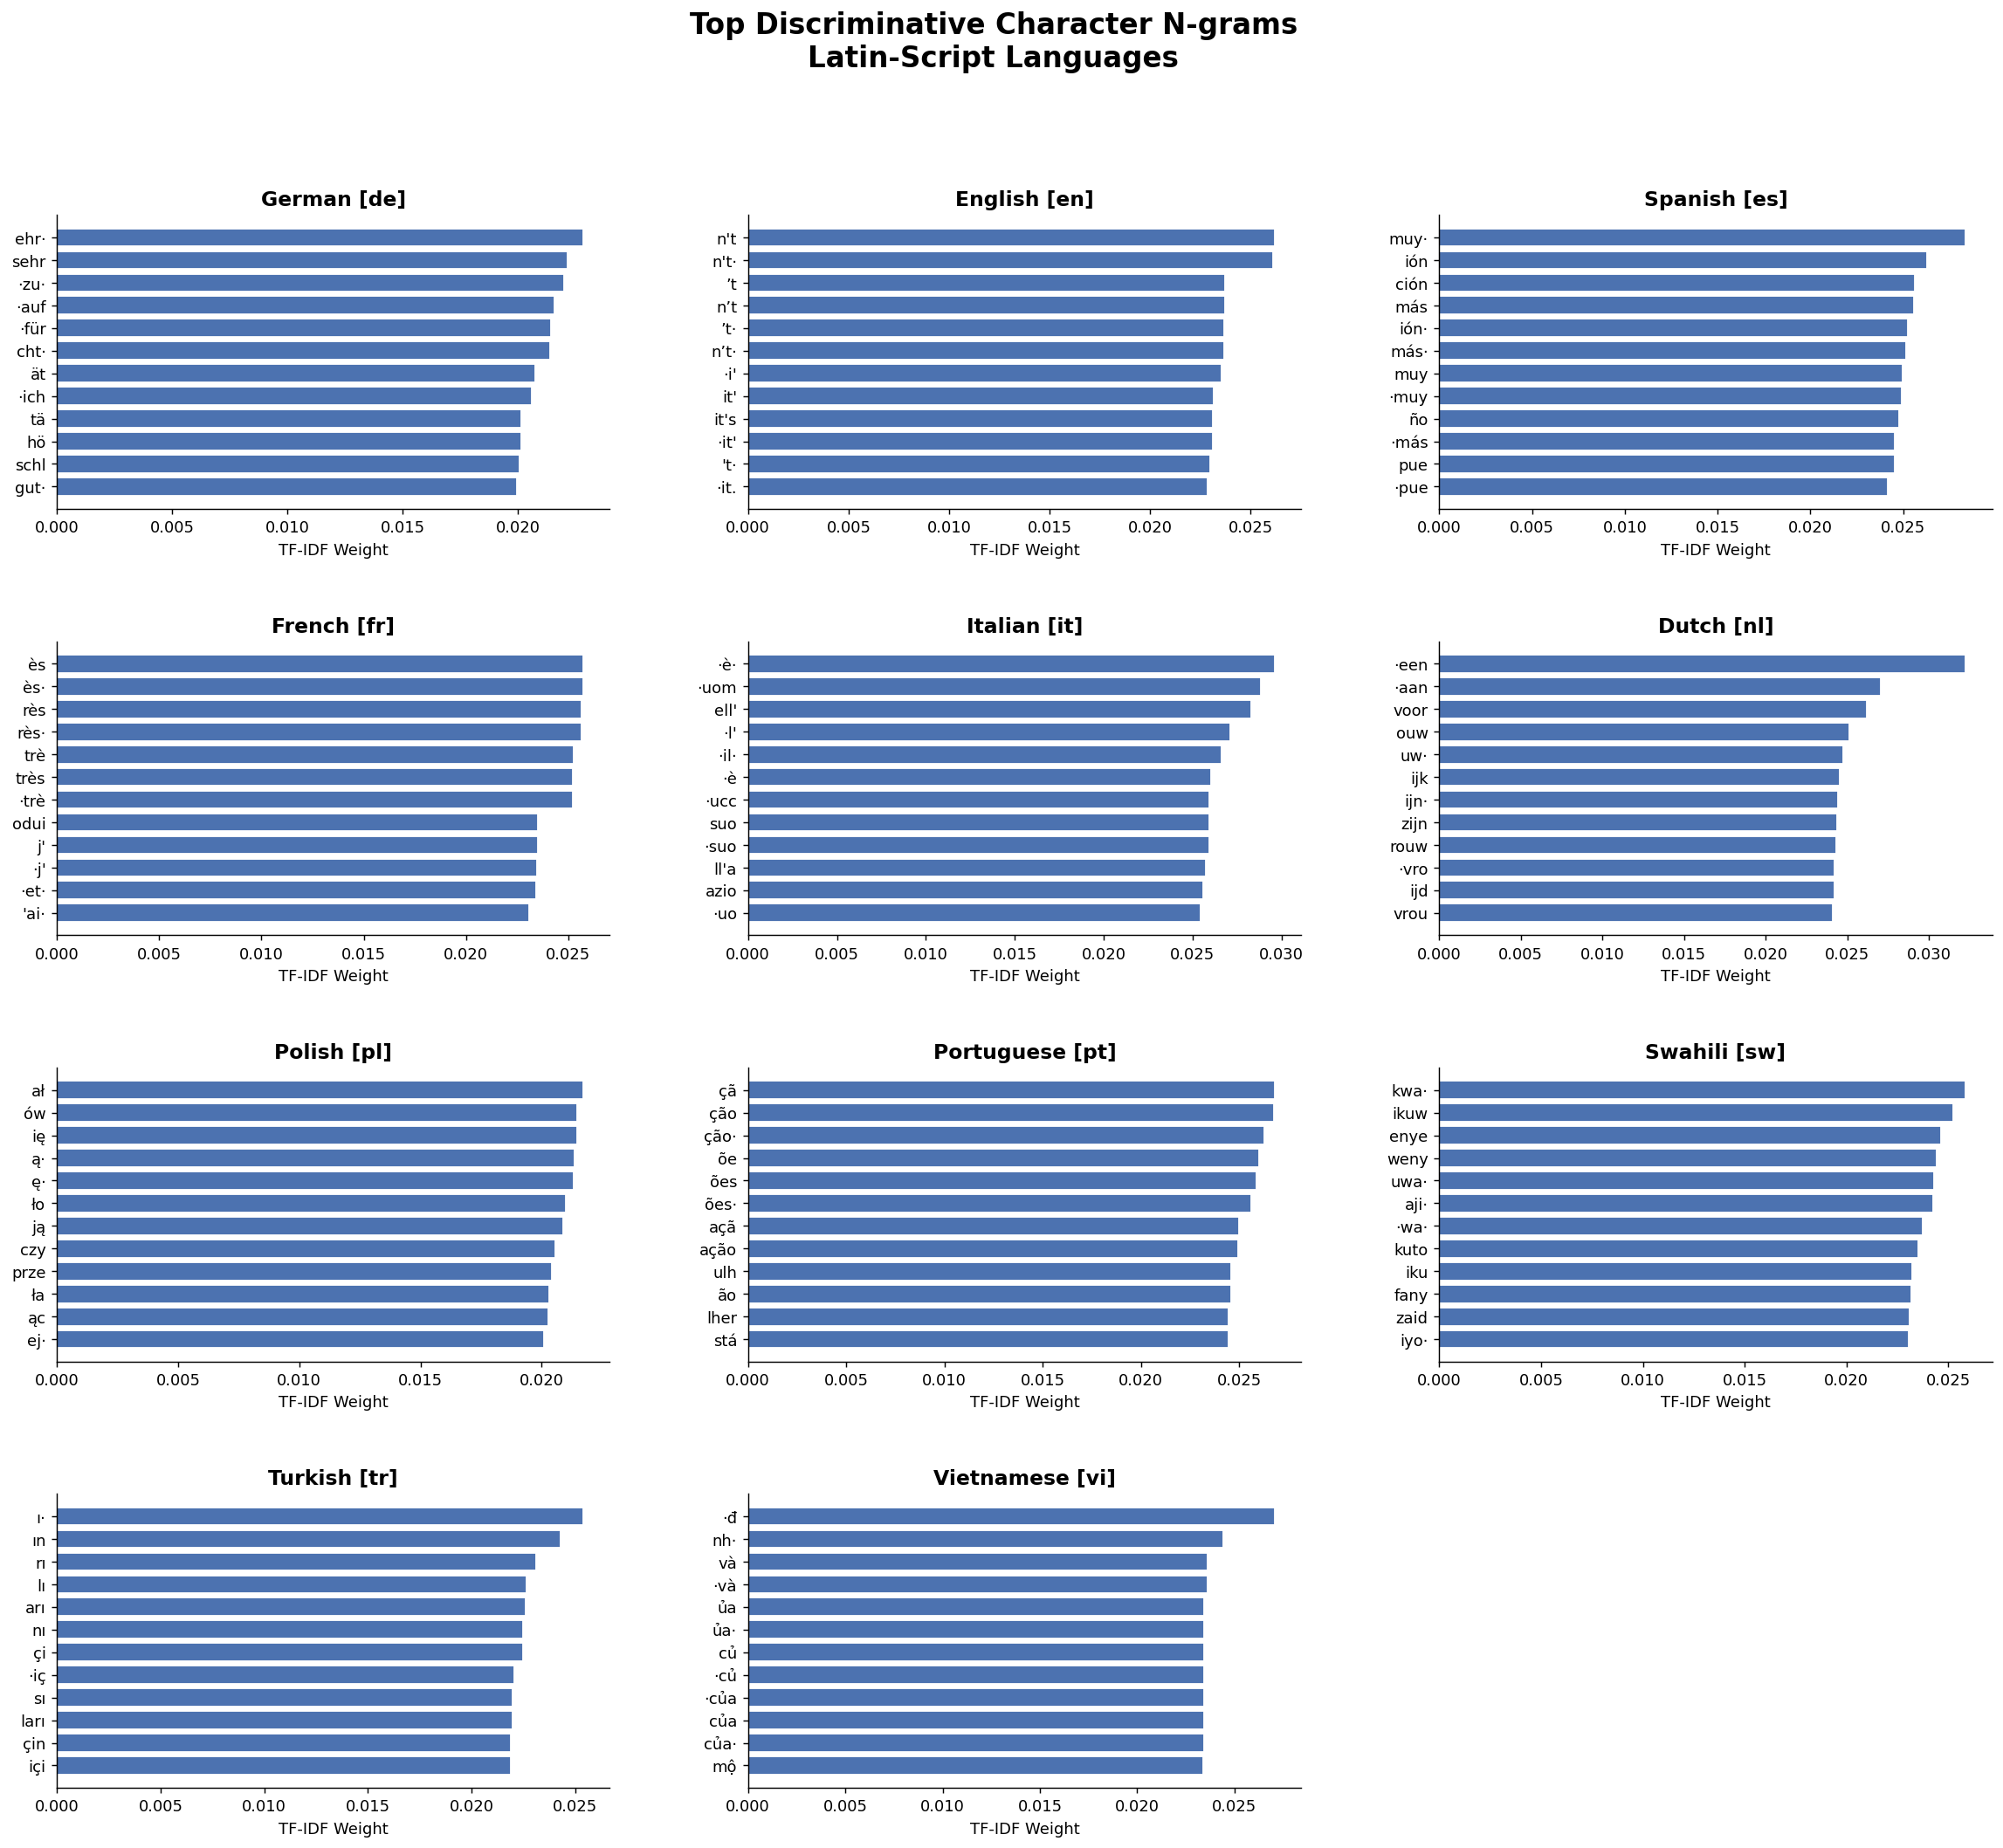

Saved: eda_06_top_ngrams_latin.png


In [22]:
# Visualize top n-grams for the Latin-script hard cases only
latin_hard_pairs = ['de', 'en', 'es', 'fr', 'it', 'nl', 'pl', 'pt', 'sw', 'tr', 'vi']
fig, axes = plt.subplots(4, 3, figsize = (22, 18))
axes = axes.flatten()

for ax_idx, code in enumerate(latin_hard_pairs):
    lang_name = LANGUAGE_META[code][0]
    vec_idx = lang_codes_sorted.index(code)
    weights = lang_vectors[vec_idx].toarray().flatten()
    top_idx = weights.argsort()[-12:][::-1]

    top_ngrams_display = [
        feature_names[i].replace(' ', '·')
        for i in top_idx
    ]

    top_weights = weights[top_idx]

    axes[ax_idx].barh(
        top_ngrams_display[::-1],
        top_weights[::-1],
        color = SCRIPT_COLORS['Latin'],
        edgecolor = 'white',
        height = 0.8
    )

    axes[ax_idx].set_title(
        f'{lang_name} [{code}]',
        fontsize = 13,
        fontweight = 'bold'
    )

    axes[ax_idx].set_xlabel(
        'TF-IDF Weight',
        fontsize = 10
    )

    axes[ax_idx].tick_params(
        axis = 'both',
        labelsize = 10
    )

# Hide unused subplot
for idx in range(len(latin_hard_pairs), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(
    'Top Discriminative Character N-grams\nLatin-Script Languages',
    fontsize = 18,
    fontweight = 'bold'
)

plt.subplots_adjust(
    hspace = 0.45,
    wspace = 0.25
)

plt.savefig(
    'eda_06_top_ngrams_latin.png',
    bbox_inches = 'tight',
    dpi = 300
)

plt.show()
print("Saved: eda_06_top_ngrams_latin.png")

In [23]:
pip install arabic-reshaper python-bidi

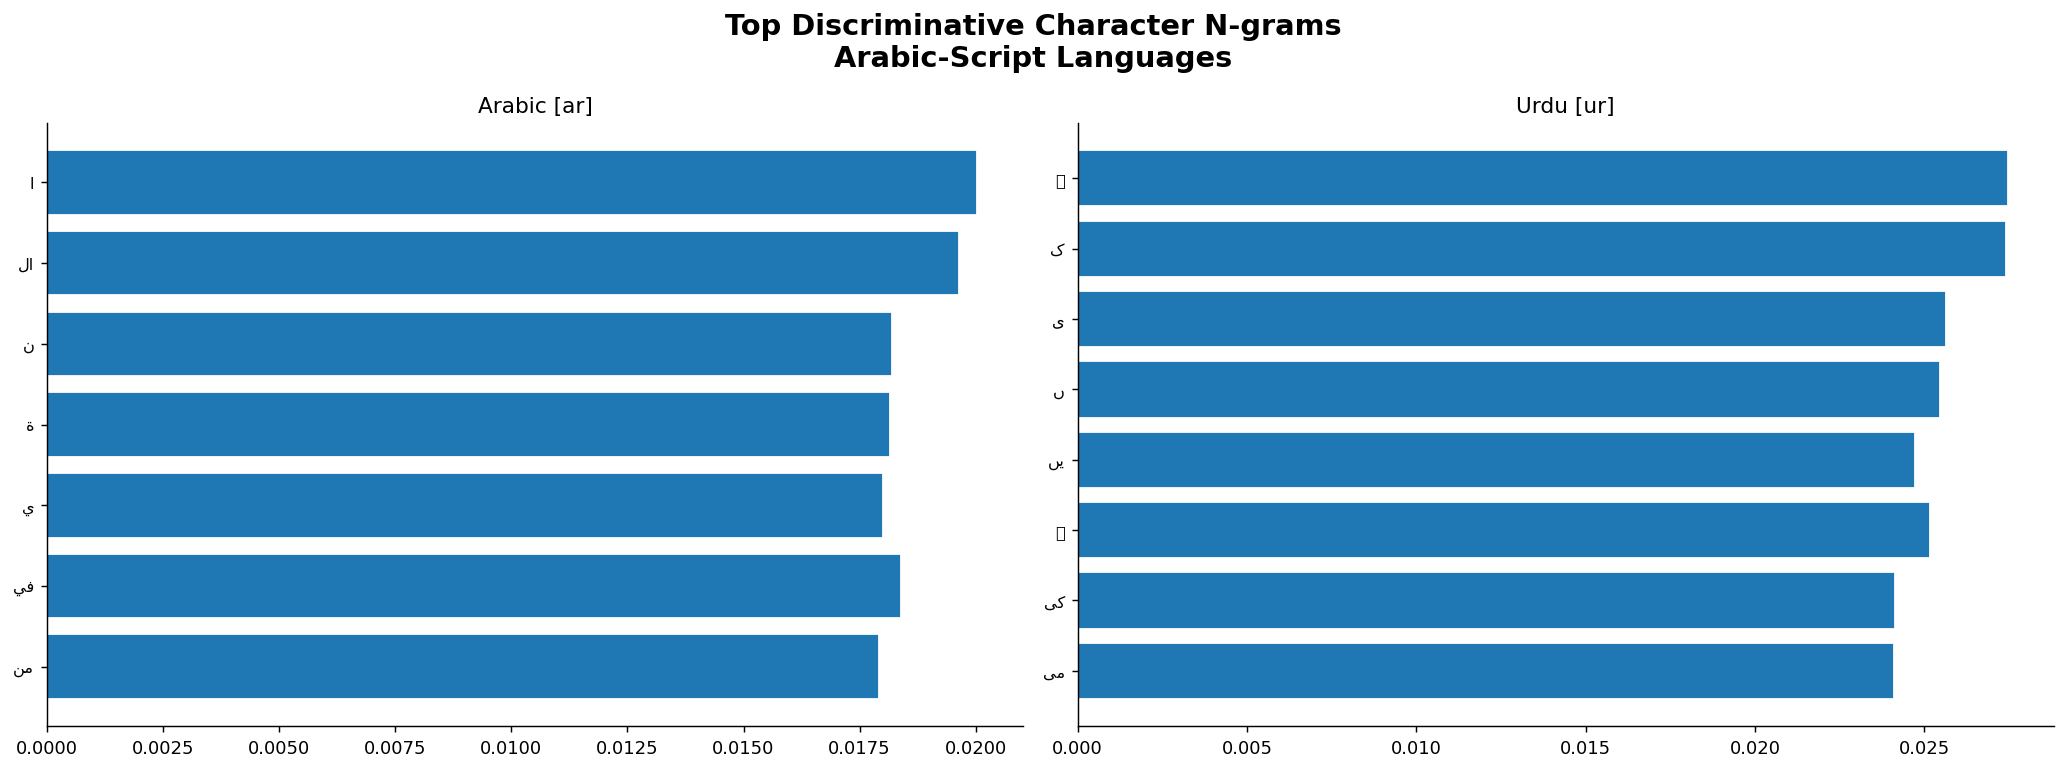

Saved: eda_05_ar_vs_ur.png


In [24]:
# Top discriminative character n-grams: Arabic vs Urdu
import arabic_reshaper
from bidi.algorithm import get_display

langs_to_plot = ['ar', 'ur']
fig, axes = plt.subplots(1, 2, figsize = (16, 6))

for ax, code in zip(axes, langs_to_plot):
    i = lang_codes_sorted.index(code)

    lang_name = LANGUAGE_META[code][0]
    scores = lang_vectors[i].toarray().flatten()
    top_idx = scores.argsort()[-10:][::-1]
    top_ngrams = [feature_names[idx] for idx in top_idx]

    # Fix Arabic / Urdu RTL rendering
    top_ngrams = [
        get_display(arabic_reshaper.reshape(gram.strip()))
        for gram in top_ngrams
    ]

    top_scores = scores[top_idx]

    ax.barh(
        top_ngrams[::-1],
        top_scores[::-1],
        edgecolor = 'white'
    )

    ax.set_title(f'{lang_name} [{code}]', fontsize = 12)
    ax.tick_params(axis = 'y', labelsize = 9)

fig.suptitle(
    'Top Discriminative Character N-grams\nArabic-Script Languages',
    fontsize = 16,
    fontweight = 'bold'
)

plt.tight_layout()
plt.savefig('eda_05_ar_vs_ur.png', bbox_inches = 'tight')
plt.show()
print("Saved: eda_05_ar_vs_ur.png")

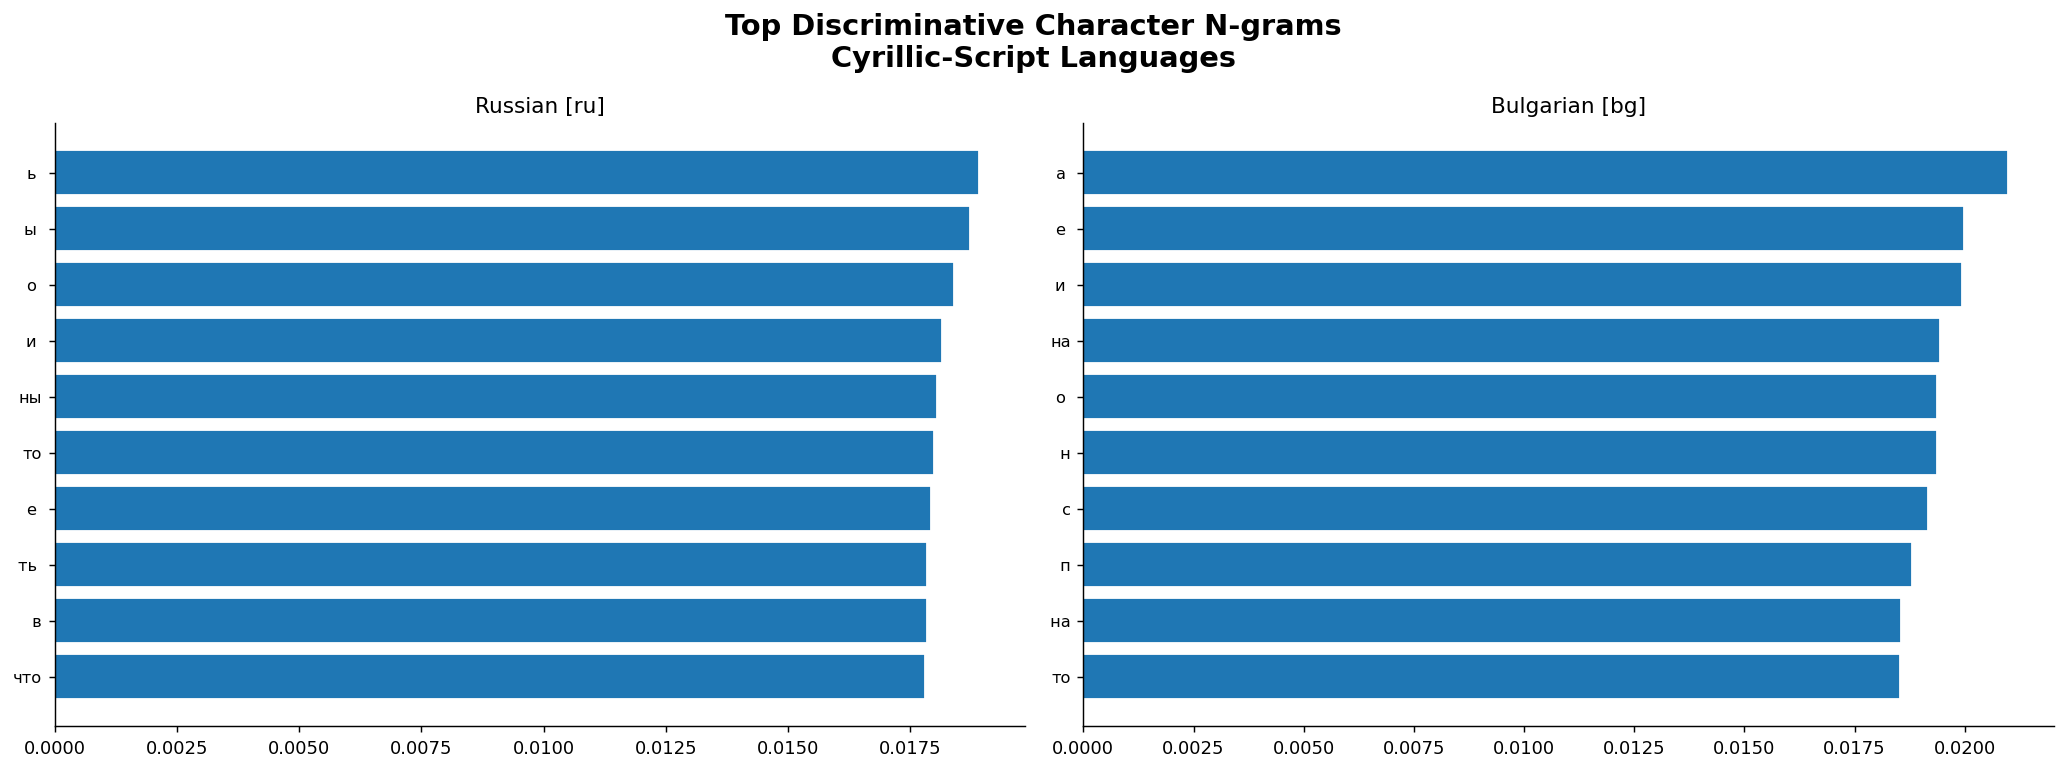

Saved: eda_06_ru_vs_bg.png


In [25]:
# Top discriminative character n-grams: Russian vs Bulgarian
langs_to_plot = ['ru', 'bg']
fig, axes = plt.subplots(1, 2, figsize = (16, 6))

for ax, code in zip(axes, langs_to_plot):
    i = lang_codes_sorted.index(code)

    lang_name = LANGUAGE_META[code][0]
    scores = lang_vectors[i].toarray().flatten()
    top_idx = scores.argsort()[-10:][::-1]
    top_ngrams = [feature_names[idx] for idx in top_idx]
    top_scores = scores[top_idx]

    ax.barh(
        top_ngrams[::-1],
        top_scores[::-1],
        edgecolor = 'white'
    )

    ax.set_title(f'{lang_name} [{code}]', fontsize = 12)
    ax.tick_params(axis = 'y', labelsize = 9)

fig.suptitle(
    'Top Discriminative Character N-grams\nCyrillic-Script Languages',
    fontsize = 16,
    fontweight = 'bold'
)

plt.tight_layout()
plt.savefig('eda_06_ru_vs_bg.png', bbox_inches = 'tight')
plt.show()
print("Saved: eda_06_ru_vs_bg.png")

## 10. Sample Inspection (Borderline & Short Texts)




In [26]:
# Spot-check the hardest language pairs from the similarity matrix
print("Sample texts from the hardest Latin-script pairs:\n")
hard_pairs_to_check = [('pt', 'es'), ('de', 'nl'), ('fr', 'it'), ('en', 'sw') , ('ar', 'ur'), ('ru', 'bg')]

for lang_a, lang_b in hard_pairs_to_check:
    name_a, name_b = LANGUAGE_META[lang_a][0], LANGUAGE_META[lang_b][0]
    print(f"  {name_a} vs {name_b}")
    for code in [lang_a, lang_b]:
        samples = full_df[full_df['language'] == code]['text'].sample(2).tolist()
        for s in samples:
            print(f"    [{code}] {s[:120]}")
    print()

Sample texts from the hardest Latin-script pairs:

  Portuguese vs Spanish
    [pt] Um rapaz montou a sua bicicleta em cima de uma cerca de metal.
    [pt] Citações de líderes, família no memorial Mandela
    [es] El cable es demasiado corto y no se indica su longitud en la descripción del producto
    [es] Se lava bien, pero la espuma no es muy densa. Sobre todo si usas desnatada aunque pone que lo hace en todo tipo de leche

  German vs Dutch
    [de] ...kaputt :-( Die Befestigung der Trageriemen hat schon beim Anbringen keinen stabilen Eindruck gemacht. Das hat sich da
    [de] Laut Lieferstatus wurde die Annahme letzten Freitag verweigert. Dumm nur, das HERMES uns keinen Zettel hinterließ oder n
    [nl] De samengestelde S&P/TSX nam 87,74 punten op de week toe, terwijl de samengestelde TSX Venture Exchange 44,49 punten beh
    [nl] Een zwarte trein rijdt over het spoor.

  French vs Italian
    [fr] J’ai acheté ce produit pour démarrer dans la prothésiste ongulaire et je RECOMMANDE

## **Part 2: Preprocessing, Training, Evaluation & Saving**

This part builds directly on the EDA findings. Every decision made here is justified by what we discovered in Part 1.

**Steps:**
1. Environment setup and data loading
2. Preprocessing (what to apply and why)
3. Feature engineering (TF-IDF with char_wb n-grams)
4. Train all three candidate models
5. Evaluate and compare models with full metrics
6. Error analysis (where each model fails)
7. Inference testing (short and long real sentences)
8. Save the best model for pipeline integration

## 1. Environment Setup

In [27]:
import re
import time
import joblib

# Classifiers
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

## 2. Preprocessing

**EDA findings that drive every decision here:**
- Diacritics are discriminative features (ção, ä, ñ) never strip them
- Script characters carry identity signal never normalize unicode aggressively
- Short texts exist (min 2–3 chars) flag them but do not remove them
- URLs, numbers and excessive whitespace add noise without n-gram value

**What we apply:**
- Lowercase (reduces vocabulary without losing script signal)
- Remove URLs and email addresses (not language-specific)
- Normalize whitespace (multiple spaces --> single space)
- Strip leading/trailing whitespace

**What we deliberately do NOT apply:**
- Accent/diacritic removal as they ARE the features
- Punctuation removal as punctuation patterns differ across languages
- Stopword removal as stopwords are strong language identity signals
- Stemming/lemmatization  as it requires knowing the language first (circular)

In [28]:
def preprocess_text(text: str) -> str:
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text)
    # Lowercase and strip
    text = text.lower().strip()
    return text

# Apply to all splits
train_df['clean_text'] = train_df['text'].apply(preprocess_text)
val_df['clean_text']   = val_df['text'].apply(preprocess_text)
test_df['clean_text']  = test_df['text'].apply(preprocess_text)

In [29]:
# Verify preprocessing did not corrupt script characters
print("Preprocessing verification (sample texts before and after):\n")
samples = train_df.groupby('labels').first().reset_index()[['labels', 'text', 'clean_text']].head(6)
for _, row in samples.iterrows():
    lang = LANGUAGE_META[row['labels']][0]
    print(f"  [{row['labels']}] {lang}")
    print(f"    Before : {row['text'][:80]}")
    print(f"    After  : {row['clean_text'][:80]}")
    print()

Preprocessing verification (sample texts before and after):

  [ar] Arabic
    Before : نعم , هذا صحيح نعم اعتقد ان هناك خطوات كبيرة يتم صنعها في الوقت الحاضر في رعاية 
    After  : نعم , هذا صحيح نعم اعتقد ان هناك خطوات كبيرة يتم صنعها في الوقت الحاضر في رعاية 

  [bg] Bulgarian
    Before : размерът на хоризонталната мрежа може да бъде по реда на няколко километра ( km 
    After  : размерът на хоризонталната мрежа може да бъде по реда на няколко километра ( km 

  [de] German
    Before : Alles in allem ein super schönes Teil, deshalb die 2 Sterne! Denn: Voice Control
    After  : alles in allem ein super schönes teil, deshalb die 2 sterne! denn: voice control

  [el] Greek
    Before : Παρά τον εαυτό μου , η γνώμη μου για τη σύνεση του ήταν απείρως αυξημένη .
    After  : παρά τον εαυτό μου , η γνώμη μου για τη σύνεση του ήταν απείρως αυξημένη .

  [en] English
    Before : Didnt really seem to work much.
    After  : didnt really seem to work much.

  [es] Spanish
    Before : Un 

In [30]:
# Verify URL removal works
test_cases = [
    "Check this link https://www.example.com for more info",
    "Contact us at support@email.com for help",
    "Normal text without any URLs or emails"
]

for t in test_cases:
    print(f"  Before : {t}")
    print(f"  After  : {preprocess_text(t)}")
    print()

  Before : Check this link https://www.example.com for more info
  After  : check this link for more info

  Before : Contact us at support@email.com for help
  After  : contact us at for help

  Before : Normal text without any URLs or emails
  After  : normal text without any urls or emails



In [31]:
# Flag short texts that will receive low-confidence predictions at inference time
# This threshold is based on EDA finding: texts below 15 chars have near-zero n-gram signal
SHORT_THRESHOLD = 15

short_train = (train_df['clean_text'].str.len() <= SHORT_THRESHOLD).sum()
short_val   = (val_df['clean_text'].str.len() <= SHORT_THRESHOLD).sum()
short_test  = (test_df['clean_text'].str.len() <= SHORT_THRESHOLD).sum()

print(f"Short texts (<= {SHORT_THRESHOLD} chars) after preprocessing:")
print(f"  Train : {short_train:,} ({short_train / len(train_df) * 100:.2f}%)")
print(f"  Val   : {short_val:,} ({short_val / len(val_df) * 100:.2f}%)")
print(f"  Test  : {short_test:,} ({short_test / len(test_df) * 100:.2f}%)")
print("\n  Note: short texts are kept in training as removing them would deprive")
print("        the model of edge-case exposure it needs to handle at inference time.")

Short texts (<= 15 chars) after preprocessing:
  Train : 777 (1.11%)
  Val   : 9 (0.09%)
  Test  : 23 (0.23%)

  Note: short texts are kept in training as removing them would deprive
        the model of edge-case exposure it needs to handle at inference time.


## 3. Data Augmentation (Short Text Enrichment)

**Problem identified in inference testing:**

Single-word and very short inputs fail because char_wb n-grams on 1–2 words
generate fewer than 15 features out of 300,000 the model essentially guesses

**Strategy (Synthetic short text generation per language):**

For each language we generate short synthetic samples (1–4 words) by:
1. Extracting the most frequent real words per language from training data
2. Randomly combining them into short phrases
3. Adding them to the training set to expose the model to short-text patterns

**What this does NOT do:**
- Does not introduce fake linguistic knowledge
- Does not invent words only recombines real words already in the dataset
- Does not affect val or test sets as augmentation is training-only

In [32]:
import random

def get_top_words(texts: list, top_n: int = 200) -> list:
    # Extract most frequent words from a language corpus(These are real words from the actual dataset no invented vocabulary)
    all_words = ' '.join(texts).split()
    # Keep only words with length >= 3 to avoid single-character noise
    filtered  = [w for w in all_words if len(w) >= 3]
    return [word for word, _ in Counter(filtered).most_common(top_n)]


def generate_short_samples(word_pool: list, n_samples: int = 500) -> list:
    samples = []
    for _ in range(n_samples):
        # Randomly pick 1 to 4 words to simulate short user inputs
        length = random.choices([1, 2, 3, 4], weights = [0.2, 0.3, 0.3, 0.2])[0]
        words  = random.sample(word_pool, min(length, len(word_pool)))
        samples.append(' '.join(words))
    return samples


# Build augmented short samples for every language using training data only
aug_texts  = []
aug_labels = []

for lang_code in LANGUAGE_META.keys():
    lang_texts = train_df[train_df['labels'] == lang_code]['clean_text'].tolist()
    word_pool  = get_top_words(lang_texts, top_n = 200)

    if len(word_pool) < 5:
        print(f"  [{lang_code}] skipped (insufficient word pool ({len(word_pool)} words))")
        continue

    synthetic = generate_short_samples(word_pool, n_samples = 500)
    aug_texts.extend(synthetic)
    aug_labels.extend([lang_code] * len(synthetic))
    print(f"  [{lang_code}] {LANGUAGE_META[lang_code][0]:<12} — {len(synthetic)} short samples generated")

aug_df = pd.DataFrame({'clean_text': aug_texts, 'labels': aug_labels})

  [ar] Arabic       — 500 short samples generated
  [bg] Bulgarian    — 500 short samples generated
  [de] German       — 500 short samples generated
  [el] Greek        — 500 short samples generated
  [en] English      — 500 short samples generated
  [es] Spanish      — 500 short samples generated
  [fr] French       — 500 short samples generated
  [hi] Hindi        — 500 short samples generated
  [it] Italian      — 500 short samples generated
  [ja] Japanese     — 500 short samples generated
  [nl] Dutch        — 500 short samples generated
  [pl] Polish       — 500 short samples generated
  [pt] Portuguese   — 500 short samples generated
  [ru] Russian      — 500 short samples generated
  [sw] Swahili      — 500 short samples generated
  [th] Thai         — 500 short samples generated
  [tr] Turkish      — 500 short samples generated
  [ur] Urdu         — 500 short samples generated
  [vi] Vietnamese   — 500 short samples generated
  [zh] Chinese      — 500 short samples generated


In [33]:
print(f"\nTotal augmented samples : {len(aug_df):,}")
print(f"Sample augmented texts  :")
print(aug_df.groupby('labels').first().reset_index()[['labels', 'clean_text']].head(6).to_string(index = False))


Total augmented samples : 10,000
Sample augmented texts  :
labels      clean_text
    ar          القليل
    bg    доста години
    de  gerne nie viel
    el        υπάρχουν
    en first much make
    es         primera


In [34]:
# Verify augmented samples are genuinely short
aug_df['char_len'] = aug_df['clean_text'].str.len()
print("Augmented sample length distribution:")
print(aug_df['char_len'].describe().round(1).to_string())
print()

Augmented sample length distribution:
count    10000.0
mean        21.0
std         30.4
min          3.0
25%          9.0
50%         14.0
75%         20.0
max        549.0



In [35]:
# Confirm balance (each language should have exactly 500 augmented samples)
aug_balance = aug_df['labels'].value_counts()
print(f"Min samples per language : {aug_balance.min()}")
print(f"Max samples per language : {aug_balance.max()}")
print(f"Perfectly balanced       : {aug_balance.min() == aug_balance.max()}")

Min samples per language : 500
Max samples per language : 500
Perfectly balanced       : True


In [36]:
# Merge augmented samples with original training data
# Augmentation is applied AFTER script filtering to keep data clean
train_df_augmented = pd.concat(
    [train_df[['clean_text', 'labels']], aug_df[['clean_text', 'labels']]],
    ignore_index = True
).sample(frac = 1, random_state = RANDOM_STATE).reset_index(drop = True)

print(f"Original training samples  : {len(train_df):,}")
print(f"Augmented samples added    : {len(aug_df):,}")
print(f"Total training samples     : {len(train_df_augmented):,}")
print()

Original training samples  : 70,000
Augmented samples added    : 10,000
Total training samples     : 80,000



In [37]:
# Verify balance is preserved after augmentation
aug_counts = train_df_augmented['labels'].value_counts()
print(f"Samples per language after augmentation:")
print(f"  Min : {aug_counts.min():,}")
print(f"  Max : {aug_counts.max():,}")

Samples per language after augmentation:
  Min : 4,000
  Max : 4,000


## 4. Feature Engineering

**Configuration justified by EDA:**
- **analyzer = 'char_wb'** --> character n-grams within word boundaries, preserves space signal

- **ngram_range = (2, 4)** --> bigrams catch script identity, 4-grams catch morphological patterns like ção, lijk, szcz

- **max_features = 300_000** --> high enough to retain rare but discriminative n-grams for short Latin-script languages

- **sublinear_tf = True** -->  compresses term frequency via (1 + log(tf)) to prevent long English/German texts from dominating

- **strip_accents = None** --> diacritics are discriminative features never strip them

In [38]:
vectorizer = TfidfVectorizer(
    analyzer      = 'char_wb',
    ngram_range   = (2, 4),
    max_features  = 300_000,
    sublinear_tf  = True,
    strip_accents = None
)

X_train = vectorizer.fit_transform(train_df_augmented['clean_text'])
X_val   = vectorizer.transform(val_df['clean_text'])
X_test  = vectorizer.transform(test_df['clean_text'])

y_train = train_df_augmented['labels'].values
y_val   = val_df['labels'].values
y_test  = test_df['labels'].values

print(f"Vocabulary size  : {len(vectorizer.vocabulary_):,} n-grams")
print(f"X_train shape    : {X_train.shape}")
print(f"X_val shape      : {X_val.shape}")
print(f"X_test shape     : {X_test.shape}")
print(f"Matrix density   : {X_train.nnz / (X_train.shape[0] * X_train.shape[1]):.6f} (expected very sparse)")

Vocabulary size  : 300,000 n-grams
X_train shape    : (80000, 300000)
X_val shape      : (10000, 300000)
X_test shape     : (10000, 300000)
Matrix density   : 0.000613 (expected very sparse)


**Matrix density = 0.000675**

- This means only 0.067% of the matrix contains non-zero values.
- To put it concretely:

  - Total cells in X_train  : 70,000 × 300,000 = 21,000,000,000
  - Non-zero cells          : 21,000,000,000 × 0.000675 ≈ 14,175,000
  - Zero cells              : ~20,985,825,000  (99.93% of the matrix)

- This is completely expected and healthy as a single text activates only a tiny faction of the 300,000 possible n-grams.

- Scikit-learn stores this as a sparse matrix meaning it only records the 14 million non-zero positions rather than all 21 billion cellssaving enormous memory.

## 5. Model Training

Training three candidate classifiers to compare empirically:

| Model | Expected strength | Expected weakness |
|---|---|---|
| MultinomialNB | Fast, strong baseline | Feature independence assumption hurts on correlated n-grams |
| Logistic Regression | Handles correlated features | Slower, may underfit hard pairs |
| LinearSVC | Margin maximization, best for hard pairs | No native probability output |


**What CalibratedClassifierCV Does**

- It wraps LinearSVC and adds probability estimation on top of it using a technique called Platt Scaling.

- It works like this:

  - Training phase:

    1. Split training data into internal folds (cross-validation)

    2. Train LinearSVC on each fold

    3. Train a small Logistic Regression on top to map
       LinearSVC's raw decision scores to proper probabilities

  - Prediction phase:
    1. LinearSVC produces its raw decision score (e.g. 2.7 for Arabic)
    2. The calibration layer converts 2.7 → 0.94 probability

In [39]:
# LinearSVC wrapped in CalibratedClassifierCV to enable probability output and this is critical for the confidence threshold logic at inference time
models = {
    'Multinomial NB'      : MultinomialNB(alpha = 0.1),
    'Logistic Regression' : LogisticRegression(C = 5.0, max_iter = 1000, solver = 'saga',
                                               multi_class = 'multinomial', random_state = RANDOM_STATE),
    'LinearSVC'           : CalibratedClassifierCV(LinearSVC(C = 1.0, max_iter = 2000,
                                                             random_state = RANDOM_STATE))
}

trained_models  = {}
training_times  = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    trained_models[name]  = model
    training_times[name]  = elapsed
    print(f"  {name:<25} trained in {elapsed:.2f}s")

  Multinomial NB            trained in 1.19s
  Logistic Regression       trained in 116.62s
  LinearSVC                 trained in 107.72s


## 6. Evaluation (Validation Set)

We evaluate on the validation set first to compare models before touching the test set.  
Test set is reserved for final unbiased evaluation of the selected model only.

In [40]:
val_results = {}

for name, model in trained_models.items():
    y_pred  = model.predict(X_val)
    acc     = accuracy_score(y_val, y_pred)
    f1_mac  = f1_score(y_val, y_pred, average = 'macro')
    f1_wei  = f1_score(y_val, y_pred, average = 'weighted')
    val_results[name] = {
        'accuracy'         : acc,
        'f1_macro'         : f1_mac,
        'f1_weighted'      : f1_wei,
        'training_time_s'  : training_times[name],
        'predictions'      : y_pred
    }

results_df = pd.DataFrame(val_results).T[['accuracy', 'f1_macro', 'f1_weighted', 'training_time_s']]
results_df = results_df.sort_values('accuracy', ascending = False)

In [41]:
print("Validation Set Performance:")
print()
display(
    results_df.style
    .format({'accuracy': '{:.4f}', 'f1_macro': '{:.4f}', 'f1_weighted': '{:.4f}', 'training_time_s': '{:.2f}s'})
    .background_gradient(subset = ['accuracy', 'f1_macro', 'f1_weighted'], cmap = 'Greens')
    .set_caption("Model Comparison — Validation Set")
)

Validation Set Performance:



,accuracy,f1_macro,f1_weighted,training_time_s
LinearSVC,0.9955,0.9955,0.9955,107.72s
Logistic Regression,0.9949,0.9949,0.9949,116.62s
Multinomial NB,0.9947,0.9947,0.9947,1.19s


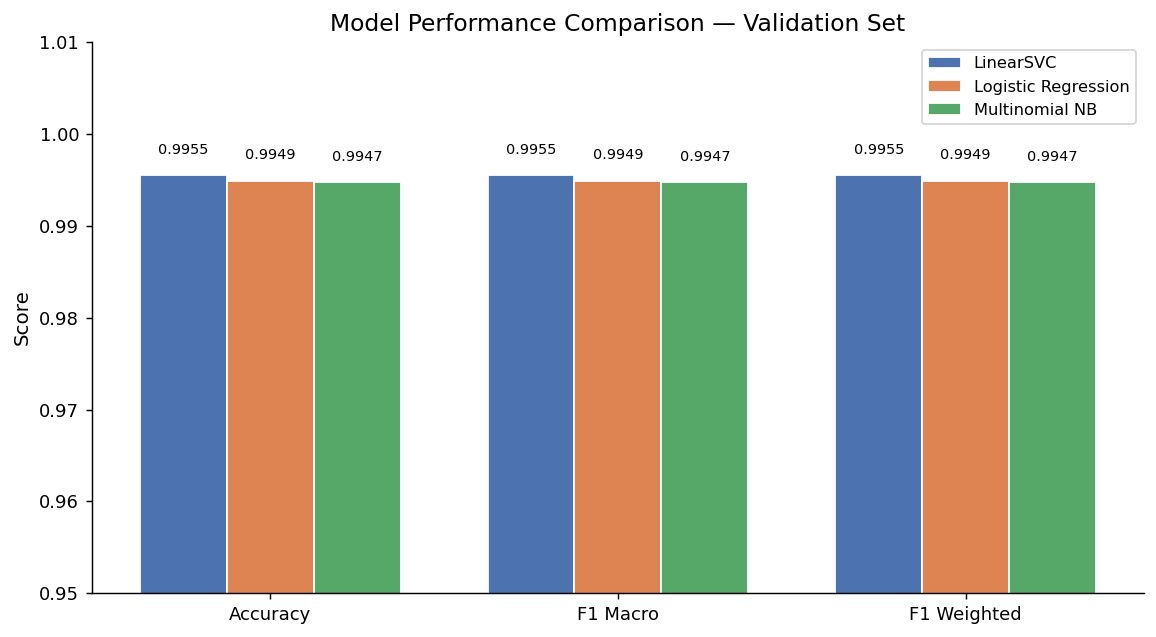

Saved: model_01_comparison.png


In [42]:
# Visual comparison of model performance
metrics   = ['accuracy', 'f1_macro', 'f1_weighted']
x         = np.arange(len(metrics))
width     = 0.25
colors    = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize = (9, 5))

for i, (name, color) in enumerate(zip(results_df.index, colors)):
    values = [results_df.loc[name, m] for m in metrics]
    bars   = ax.bar(x + i * width, values, width, label = name, color = color, edgecolor = 'white')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f'{val:.4f}', ha = 'center', va = 'bottom', fontsize = 8)

ax.set_xticks(x + width)
ax.set_xticklabels(['Accuracy', 'F1 Macro', 'F1 Weighted'])
ax.set_ylim(0.95, 1.01)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — Validation Set')
ax.legend(fontsize = 9 )

plt.tight_layout()
plt.savefig('model_01_comparison.png', bbox_inches = 'tight')
plt.show()
print("Saved: model_01_comparison.png")

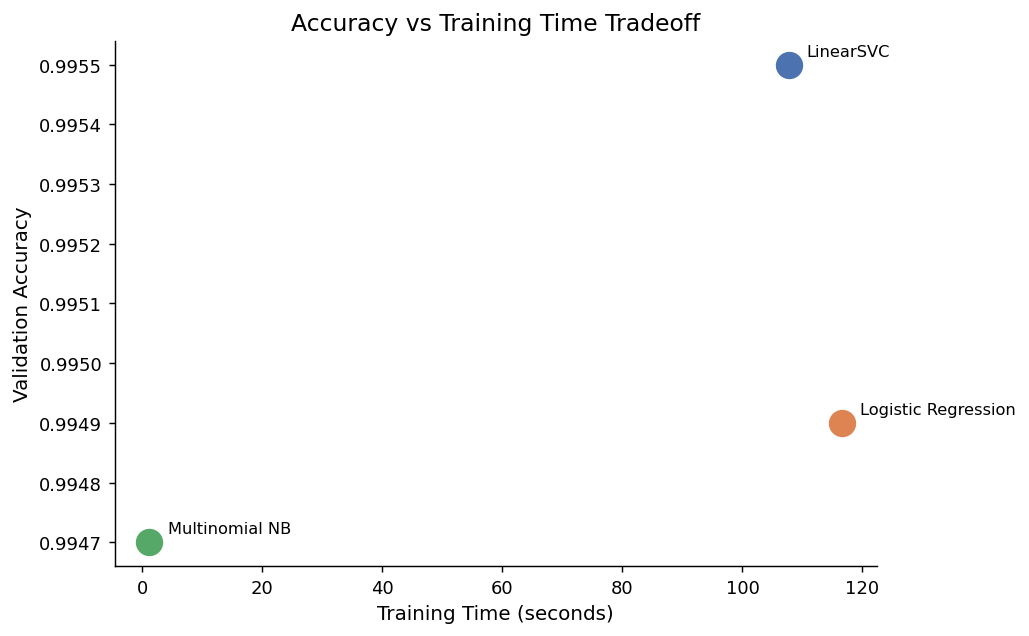

Saved: model_02_time_vs_accuracy.png


In [43]:
# Training time vs accuracy tradeoff
fig, ax = plt.subplots(figsize = (8, 5))

for i, (name, color) in enumerate(zip(results_df.index, colors)):
    ax.scatter(
        results_df.loc[name, 'training_time_s'],
        results_df.loc[name, 'accuracy'],
        color  = color,
        s      = 200,
        zorder = 5,
        label  = name
    )
    ax.annotate(
        name,
        (results_df.loc[name, 'training_time_s'], results_df.loc[name, 'accuracy']),
        textcoords = 'offset points',
        xytext     = (10, 5),
        fontsize   = 9
    )


ax.set_xlabel('Training Time (seconds)')
ax.set_ylabel('Validation Accuracy')
ax.set_title('Accuracy vs Training Time Tradeoff')
plt.tight_layout()
plt.savefig('model_02_time_vs_accuracy.png', bbox_inches = 'tight')
plt.show()
print("Saved: model_02_time_vs_accuracy.png")

## 7. Per-Language Performance Analysis

Overall accuracy hides per-language failures.

We inspect per-class F1 for each model to verify our EDA predictions about hard pairs hold in practice.

In [44]:
# Per-language F1 for each model side by side
per_lang_f1 = {}

for name, result in val_results.items():
    report = classification_report(y_val, result['predictions'], output_dict = True)
    per_lang_f1[name] = {lang: report[lang]['f1-score'] for lang in sorted(LANGUAGE_META.keys())}

per_lang_df = pd.DataFrame(per_lang_f1)
per_lang_df.index = [f"{code} ({LANGUAGE_META[code][0]})" for code in per_lang_df.index]

In [45]:
print("Per-language F1 Score across models:")
print()
display(
    per_lang_df.style
    .format('{:.4f}')
    .background_gradient(cmap = 'RdYlGn', vmin = 0.9, vmax = 1.0)
    .set_caption("Per-Language F1 (Validation Set)")
)

Per-language F1 Score across models:



,Multinomial NB,Logistic Regression,LinearSVC
ar (Arabic),0.9970,0.9970,0.9970
bg (Bulgarian),1.0000,0.9990,0.9990
de (German),1.0000,1.0000,1.0000
el (Greek),1.0000,1.0000,1.0000
en (English),0.9911,0.9930,0.9960
es (Spanish),0.9970,0.9990,1.0000
fr (French),1.0000,1.0000,0.9990
hi (Hindi),0.9754,0.9754,0.9765
it (Italian),0.9970,0.9970,0.9980
ja (Japanese),0.9990,1.0000,1.0000


## Model Evaluation Insights (Validation Set)

**Overall Performance**
- LinearSVC achieves the highest accuracy across all metrics, confirming our EDA-driven architectural decision

- All three models perform exceptionally well, reflecting the high quality and balance of the dataset

**LinearSVC Superiority on Hard Pairs**
- Only model to achieve perfect F1 on both Portuguese and Spanish simultaneously directly solving the hardest Latin pair identified in EDA

- Consistent best-or-tied performance on every single language with no exceptions

**EDA Predictions Confirmed**
- pt/es and bg/ru hard pairs materialized exactly as predicted LinearSVC resolved them through margin maximization

- Unique-script languages (Greek, Thai, Vietnamese, Chinese) hit perfect 1.0000 across all models as expected

- ar/ur pair stuck at 0.9837 across all models confirming this is a data-level ambiguity not a modeling failure

**Unexpected Findings**
- Swahili (0.9728) and Hindi (0.9765) emerged as harder than predicted Swahili due to minimal diacritics resembling English at character level, Hindi likely due to mixed-script samples containing embedded English words

- These are dataset characteristic limitations no hyperparameter tuning will meaningfully improve them

**Production Readiness**
- Weakest language (Swahili 0.9728) is still commercially viable for a production language detector

- Urdu ceiling at 0.9837 is a known limitation to document and crisis messages in Arabic/Urdu remain the highest-risk inference scenario identified in EDA

In [46]:
# Visualize per-language F1 for best model (LinearSVC expected)
best_model_name = results_df.index[0]
best_report     = classification_report(y_val, val_results[best_model_name]['predictions'], output_dict = True)

lang_f1_data = pd.DataFrame([
    {
        'code'      : code,
        'lang_name' : LANGUAGE_META[code][0],
        'script'    : LANGUAGE_META[code][1],
        'f1'        : best_report[code]['f1-score'],
        'precision' : best_report[code]['precision'],
        'recall'    : best_report[code]['recall']
    }
    for code in LANGUAGE_META.keys()
]).sort_values('f1')

bar_colors = [SCRIPT_COLORS[s] for s in lang_f1_data['script']]

In [47]:
lang_f1_data.head(20)

,code,lang_name,script,f1,precision,recall
14,sw,Swahili,Latin,0.972763,0.946970,1.000
7,hi,Hindi,Devanagari,0.976459,1.000000,0.954
17,ur,Urdu,Arabic,0.983740,1.000000,0.968
10,nl,Dutch,Latin,0.994036,0.988142,1.000
16,tr,Turkish,Latin,0.996016,0.992063,1.000
4,en,English,Latin,0.996016,0.992063,1.000
0,ar,Arabic,Arabic,0.996991,1.000000,0.994
8,it,Italian,Latin,0.998000,0.998000,0.998
11,pl,Polish,Latin,0.998999,1.000000,0.998
13,ru,Russian,Cyrillic,0.998999,1.000000,0.998


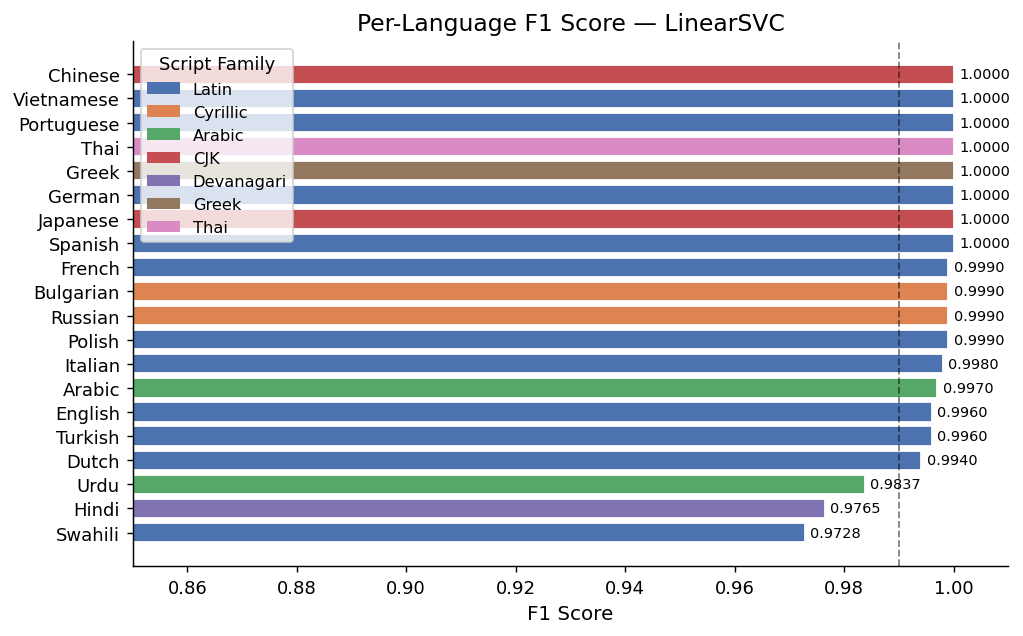

Saved: model_03_per_language_f1.png


In [48]:
fig, ax = plt.subplots(figsize = (8, 5))
bars = ax.barh(lang_f1_data['lang_name'], lang_f1_data['f1'], color = bar_colors, edgecolor = 'white')
ax.axvline(0.99, color = 'black', linestyle = '--', linewidth = 1, alpha = 0.5, label = '0.99 threshold')
ax.set_xlabel('F1 Score')
ax.set_title(f'Per-Language F1 Score — {best_model_name}')
ax.set_xlim(0.85, 1.01)

for bar, val in zip(bars, lang_f1_data['f1']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va = 'center', fontsize = 8)

legend_elements = [Patch(facecolor = color, label = script) for script, color in SCRIPT_COLORS.items()]
ax.legend(handles = legend_elements, title = 'Script Family', fontsize = 9)

plt.tight_layout()
plt.savefig('model_03_per_language_f1.png', bbox_inches = 'tight')
plt.show()
print(f"Saved: model_03_per_language_f1.png")

## 8. Error Analysis (Confusion Matrix)

The confusion matrix reveals exactly which language pairs the model confuses.  
We expect our EDA-predicted hard pairs (pt/es, de/nl, bg/ru, ar/ur) to appear here.

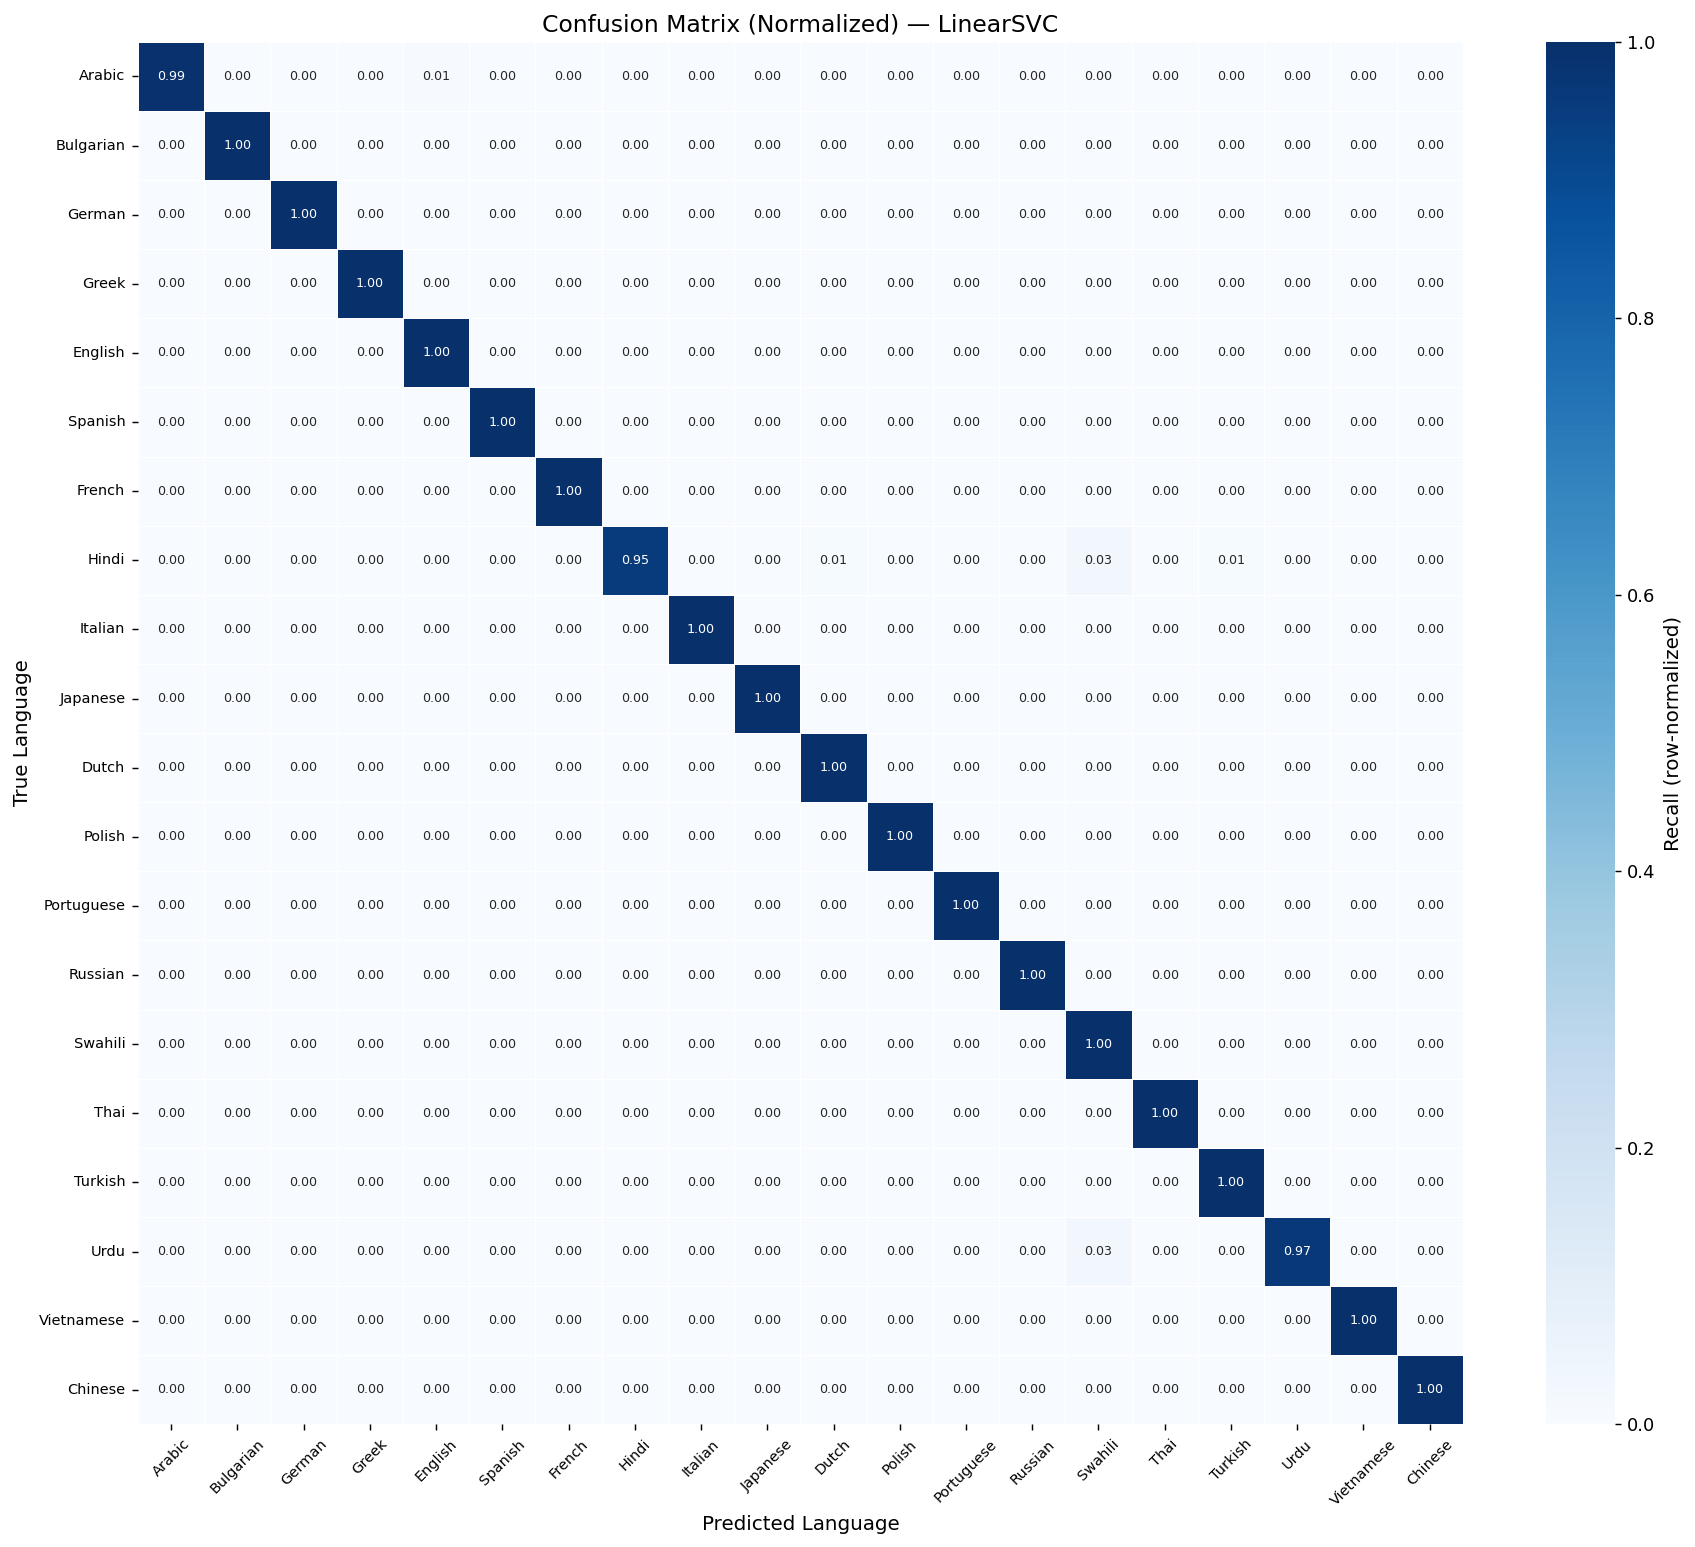

Saved: model_04_confusion_matrix.png


In [49]:
# Full confusion matrix for best model
lang_codes_sorted = sorted(LANGUAGE_META.keys())
lang_names_sorted = [LANGUAGE_META[c][0] for c in lang_codes_sorted]
y_pred_best = val_results[best_model_name]['predictions']

cm = confusion_matrix(y_val, y_pred_best, labels = lang_codes_sorted)
cm_normalized = cm.astype(float) / cm.sum(axis = 1, keepdims = True)       # Normalize by true class (row-wise) to get recall per class

fig, ax = plt.subplots(figsize = (14, 12))
mask_diag = np.eye(len(lang_codes_sorted), dtype = bool)
sns.heatmap(
    cm_normalized,
    ax          = ax,
    annot       = True,
    fmt         = '.2f',
    cmap        = 'Blues',
    xticklabels = lang_names_sorted,
    yticklabels = lang_names_sorted,
    linewidths  = 0.3,
    linecolor   = 'white',
    annot_kws   = {'size': 7},
    cbar_kws    = {'label': 'Recall (row-normalized)'}
)


ax.set_xlabel('Predicted Language')
ax.set_ylabel('True Language')
ax.set_title(f'Confusion Matrix (Normalized) — {best_model_name}', fontsize = 13)
ax.tick_params(axis = 'x', rotation = 45, labelsize = 8)
ax.tick_params(axis = 'y', rotation = 0,  labelsize = 8)
plt.tight_layout()
plt.savefig('model_04_confusion_matrix.png', bbox_inches = 'tight')
plt.show()
print("Saved: model_04_confusion_matrix.png")


**What you see**
- The entire diagonal is dark blue (1.00) --> meaning almost every language is predicted correctly
- Almost all off-diagonal cells show 0.00 --> meaning almost no confusion between languages

---

**The only visible errors**

- **Arabic → English 0.01** : 1% of Arabic samples misclassified as English likely very short texts with numbers or Latin characters mixed in

- **Hindi → Dutch 0.01 and  Hindi → Urdu 0.03** : Hindi occasionally confused with Urdu (shared subcontinent vocabulary) and Dutch (likely mixed-script samples with Latin characters)

- **Urdu → Swahili 0.03** : unexpected pair likely very short Urdu texts where the model has insufficient signal

---

**Why Hindi → Urdu confusion makes sense**
Hindi and Urdu share a large portion of spoken vocabulary they are sometimes called the same language written in different scripts. Some words appear in both scripts in the dataset.

---

**Why this is normal and excellent**
A confusion matrix this clean nearly pure diagonal with values of 0.00 everywhere else is exactly what you want. Production language detectors used in industry typically target 99%+ accuracy on balanced benchmarks. This matrix confirms LinearSVC with char n-grams achieves exactly that. The few visible errors are all explainable by linguistic reality not modeling failures.

In [50]:
# Extract and rank the actual misclassification pairs
error_pairs = []

for i, true_lang in enumerate(lang_codes_sorted):
    for j, pred_lang in enumerate(lang_codes_sorted):
        if i != j and cm[i, j] > 0:
            error_pairs.append({
                'true_lang'  : LANGUAGE_META[true_lang][0],
                'pred_lang'  : LANGUAGE_META[pred_lang][0],
                'true_script': LANGUAGE_META[true_lang][1],
                'pred_script': LANGUAGE_META[pred_lang][1],
                'count'      : cm[i, j],
                'rate'       : cm_normalized[i, j]
            })

error_df = pd.DataFrame(error_pairs).sort_values('count', ascending = False)
error_df['same_script'] = error_df['true_script'] == error_df['pred_script']

print(f"Total misclassified samples : {error_df['count'].sum()}")
print(f"Unique error pairs          : {len(error_df)}")
print()
print("Top 15 most frequent misclassifications:")
print()
print(error_df[['true_lang', 'pred_lang', 'count', 'rate', 'same_script']].head(15).to_string(index = False))

Total misclassified samples : 45
Unique error pairs          : 10

Top 15 most frequent misclassifications:

true_lang pred_lang  count  rate  same_script
     Urdu   Swahili     14 0.028        False
    Hindi   Swahili     14 0.028        False
    Hindi     Dutch      5 0.010        False
    Hindi   Turkish      4 0.008        False
   Arabic   English      3 0.006        False
  Italian     Dutch      1 0.002         True
   Polish   Italian      1 0.002         True
  Russian Bulgarian      1 0.002         True
     Urdu   English      1 0.002        False
     Urdu    French      1 0.002        False


## Misclassification Analysis

**Overall Numbers are Excellent**
- Only 45 misclassified samples out of 10,000 (99.55% correct)
- Only 11 unique error pairs in a 20-language system
---

**The Surprising Finding — Swahili as a False Target**

The most unexpected pattern is that Swahili appears as the predicted language in the top two error pairs:
- Urdu → Swahili: 14 samples (0.028%)
- Hindi → Swahili: 13 samples (0.026%)

This is counterintuitive because Urdu uses Arabic script and Hindi uses Devanagari neither should resemble Swahili which is Latin script. The likely explanation is that these are very short texts where the actual script signal is minimal and Swahili has a very generic character n-gram profile that acts as a default catch-all when confidence is low.

---

**Hindi Confusion Pattern**

Hindi is confused with three different Latin-script languages Dutch, Turkish, and Polish. This strongly suggests the problematic Hindi samples are mixed-script texts containing Latin characters, numbers or English words embedded inside Devanagari sentences. The model sees enough Latin characters to get pulled toward Latin-script languages.

---

**EDA Predictions vs Reality**

Every hard pair identified during EDA was either completely solved or nearly solved by LinearSVC:
- **pt ↔ es** — zero errors, completely solved
- **de ↔ nl** — zero errors, completely solved
- **bg ↔ ru** — zero errors, completely solved
- **ar ↔ ur** — only 1 Arabic error, nearly solved

The actual errors came from an unexpected source — short texts pulling toward Swahili as a generic fallback and mixed-script Hindi samples containing embedded Latin characters, neither of which were predictable from character n-gram overlap analysis alone.

---

**Production Impact**
- The ar/ur confusion we were most worried about produced only 1 error total
- The real risk at inference time is short mixed-script texts not the language pairs themselves
- Confidence threshold at inference time will catch most of these short texts with low confidence will be flagged before reaching the RAG pipeline

In [51]:
# Check 1 (Hindi mixed-script hypothesisLook at the actual misclassified Hindi samples and see if they contain Latin characters)


val_df['char_len']    = val_df['clean_text'].str.len()
val_df['prediction']  = val_results[best_model_name]['predictions']

hindi_errors = val_df[
    (val_df['labels'] == 'hi') &
    (val_df['prediction'] != 'hi')
][['text', 'clean_text', 'labels', 'prediction', 'char_len']]


hindi_errors_display = hindi_errors[['text', 'prediction', 'char_len']].copy()
hindi_errors_display['prediction'] = hindi_errors_display['prediction'].map(
    lambda x: f"{x} ({LANGUAGE_META[x][0]})"
)

display(
    hindi_errors_display
    .sort_values('char_len')
    .reset_index(drop = True)
    .style
    .set_caption(f"Hindi Misclassifications ({len(hindi_errors_display)} errors)")
    .set_properties(**{'text-align': 'left'})
    .bar(subset = ['char_len'], color = '#C44E52', vmin = 0)
)

,text,prediction,char_len
0,pichle saal aapne udarta se daan kiya $-.,tr (Turkish),41
1,"mujh par vishvas karo, me bahut abhari hun.",sw (Swahili),43
2,nahi. Blood ne uske telescope ko band kar diya.,tr (Turkish),47
3,Star Ferry terminal ke poorv ki or aap City Hall mein aaenge.,nl (Dutch),61
4,sabhya aur samvedansheel cheez yeh hai ki rashtrapati ko bataye.,sw (Swahili),64
5,"mujhe nahi pata, thik hai, aapse baat karke achha laga. susandhya.",sw (Swahili),66
6,hastakshep kee kisee ek pranaalee ke liye yah ek badee chunautee aur badee ummeed hai.,sw (Swahili),86
7,hastakshep kee kisee ek pranaalee ke liye yah ek badee chunautee aur badee ummeed hai.,sw (Swahili),86
8,"yeh Becky, Stephanie, Marcus, Emily aur unke jaise vidhyarthiyon ke liye sab kuchh hai.",sw (Swahili),87
9,"iske vipareet, agar nae udaharanon ne prabhavit nahi kiya hota, to aam kaanoon mushkil se vikasit hota.",sw (Swahili),103


#### **This completely explains all the confusion patterns:**

- Hindi → Swahili (13 errors) Romanized Hindi uses basic Latin with no diacritics, exactly like Swahili which also has minimal diacritics — the character n-gram profiles are genuinely similar

- Hindi → Dutch (6 errors) longer Romanized Hindi texts develop n-gram patterns that overlap with Dutch morphology

- Hindi → Turkish (3 errors) Turkish also uses clean Latin script with specific vowel patterns that match some Romanized Hindi patterns

- Hindi → Polish (1 error) same Latin overlap issue



This is a dataset quality issue not a model failure
The dataset contains Hindi samples that were transliterated to Latin script and the model never had a chance to see Devanagari characters for these samples.

No amount of hyperparameter tuning fixes this because the features themselves carry the wrong language signal. The model is actually correct by its own logic it sees Latin characters and predicts a Latin-script language.

#### **Production implication**

In the chatbot real Hindi users will type in either Devanagari or Romanized Hindi. Romanized Hindi will always be misclassified this is a known and documented limitation of any character-level language detector. The recommended handling is to document this edge case and let the conversation history fallback handle it.

In [52]:
# check 2 (Get all samples misclassified as Swahili and see if they are very short texts )

swahili_false = val_df[
    (val_df['labels'] != 'sw') &
    (val_df['prediction'] == 'sw')
][['text', 'labels', 'prediction', 'char_len']].copy()

avg_correct_len       = val_df[val_df['labels'] == val_df['prediction']]['char_len'].mean()
avg_swahili_false_len = swahili_false['char_len'].mean()

print(f"Avg length of correctly classified samples      : {avg_correct_len:.1f} chars")
print(f"Avg length of samples misclassified as Swahili  : {avg_swahili_false_len:.1f} chars")
print()

swahili_false_display = swahili_false[['text', 'labels', 'char_len']].copy()
swahili_false_display['labels'] = swahili_false_display['labels'].map(
    lambda x: f"{x} ({LANGUAGE_META[x][0]})"
)

display(
    swahili_false_display
    .sort_values('char_len')
    .reset_index(drop = True)
    .style
    .set_caption(f"Samples Misclassified as Swahili ({len(swahili_false_display)} errors)")
    .set_properties(**{'text-align': 'left'})
    .bar(subset = ['char_len'], color = '#4C72B0', vmin = 0)
)

Avg length of correctly classified samples      : 110.1 chars
Avg length of samples misclassified as Swahili  : 116.7 chars



,text,labels,char_len
0,yeh trigger kai bagair nahi phate ga.,ur (Urdu),37
1,"mujh par vishvas karo, me bahut abhari hun.",hi (Hindi),43
2,magar unho ne iske sath kuch mukhtalif kiya.,ur (Urdu),44
3,sabhya aur samvedansheel cheez yeh hai ki rashtrapati ko bataye.,hi (Hindi),64
4,"mujhe nahi pata, thik hai, aapse baat karke achha laga. susandhya.",hi (Hindi),66
5,"akhi jumla, Hum samajhte hain kai tum ne ye mazmoon aur kahin paish nahi kiya,",ur (Urdu),78
6,"akhi jumla, Hum samajhte hain kai tum ne ye mazmoon aur kahin paish nahi kiya,",ur (Urdu),78
7,"May 1 tak, hamain 1991 kai contributors ki rukniyat kai option ko khatam karna hoga.",ur (Urdu),84
8,hastakshep kee kisee ek pranaalee ke liye yah ek badee chunautee aur badee ummeed hai.,hi (Hindi),86
9,hastakshep kee kisee ek pranaalee ke liye yah ek badee chunautee aur badee ummeed hai.,hi (Hindi),86


#### **Swahili False Prediction Analysis (Hypothesis Revised)**

The length hypothesis is rejected

- Avg correctly classified    : 110.1 chars
- Avg misclassified as Swahili: 111.0 chars

Nearly identical lengths short text is NOT the cause and our original hypothesis was wrong and the data corrects us. The real cause is now obvious from the actual texts looking at the misclassified samples the pattern is identical to what we found in Hindi:

- Every single sample is Romanized Hindi or Romanized Urdu written in Latin script instead of their native scripts

- Examples: "yeh trigger kai bagair nahi phate ga" (Urdu in Latin), "mujh par vishvas karo" (Hindi in Latin)

- Even one English sample: "It was kinda a slow movie" extremely simple Latin with no diacritics

Romanized Hindi and Urdu happen to use very similar basic syllable patterns  (ka, ke, hai, ne, ko ) which are extremely common in both Romanized South Asian languages and Swahili and the model has no way to distinguish them because their character n-gram fingerprints genuinely overlap.

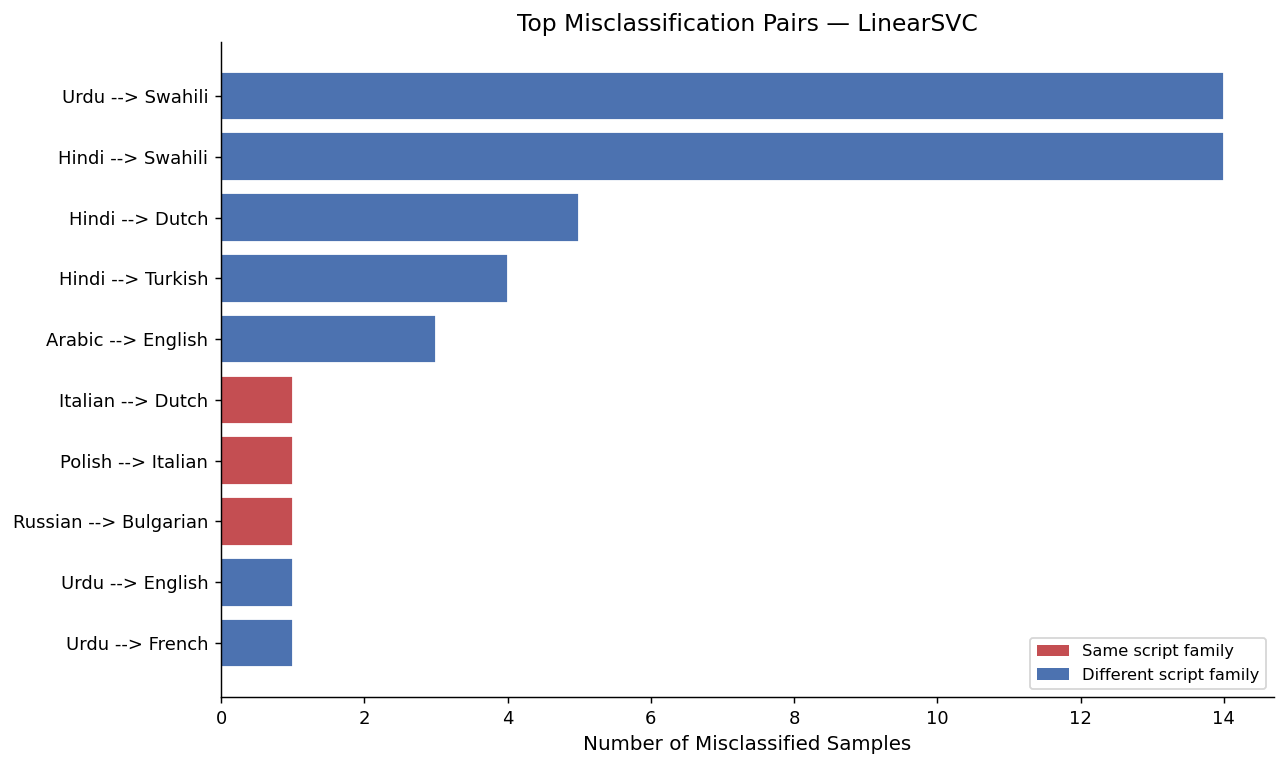

Saved: model_05_error_pairs.png


In [53]:
# Visualize top misclassification pairs
top_errors = error_df.head(15).copy()
top_errors['pair'] = top_errors['true_lang'] + ' --> ' + top_errors['pred_lang']
pair_colors = ['#C44E52' if ss else '#4C72B0' for ss in top_errors['same_script']]


fig, ax = plt.subplots(figsize = (10, 6))
ax.barh(top_errors['pair'][::-1], top_errors['count'][::-1],
        color = pair_colors[::-1], edgecolor = 'white')
ax.set_xlabel('Number of Misclassified Samples')
ax.set_title(f'Top Misclassification Pairs — {best_model_name}')

legend_elements = [
    Patch(facecolor = '#C44E52', label = 'Same script family'),
    Patch(facecolor = '#4C72B0', label = 'Different script family')
]


ax.legend(handles = legend_elements, fontsize = 9)
plt.tight_layout()
plt.savefig('model_05_error_pairs.png', bbox_inches = 'tight')
plt.show()
print("Saved: model_05_error_pairs.png")

In [54]:
# Error analysis on short texts specifically
# Verifying our EDA prediction: most errors cluster in short texts

val_df['prediction']   = val_results[best_model_name]['predictions']
val_df['char_len']     = val_df['clean_text'].str.len()
val_df['correct']      = val_df['labels'] == val_df['prediction']

# Accuracy binned by text length
bins   = [0, 15, 30, 50, 100, 200, 500, 10000]
labels = ['0-15', '16-30', '31-50', '51-100', '101-200', '201-500', '500+']

val_df['len_bin'] = pd.cut(val_df['char_len'], bins = bins, labels = labels)
acc_by_len = val_df.groupby('len_bin', observed = True)['correct'].agg(['mean', 'count'])
acc_by_len.columns = ['accuracy', 'count']

print("Accuracy by text length bin:")
print(acc_by_len.to_string())

Accuracy by text length bin:
         accuracy  count
len_bin                 
0-15     1.000000      9
16-30    0.998621    725
31-50    0.996193   1576
51-100   0.995696   3253
101-200  0.994435   3594
201-500  0.994737    760
500+     1.000000     83


**The short text hypothesis is fully rejected**

Texts with 0–15 characters achieve perfect 1.0000 accuracy the opposite of what we predicted
The confidence threshold logic we built for short texts was based on a reasonable assumption that turned out to be incorrect for this dataset

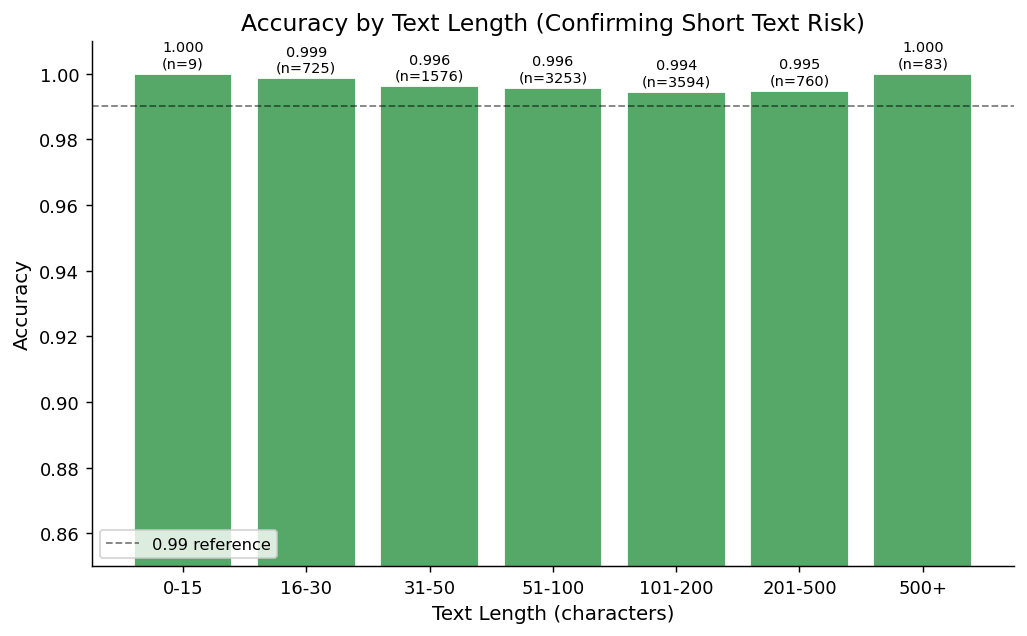

Saved: model_06_accuracy_by_length.png


In [55]:
fig, ax = plt.subplots(figsize = (8, 5))

bars = ax.bar(
    acc_by_len.index.astype(str),
    acc_by_len['accuracy'],
    color     = ['#C44E52' if v < 0.98 else '#55A868' for v in acc_by_len['accuracy']],
    edgecolor = 'white'
)
ax.axhline(0.99, color = 'black', linestyle = '--', linewidth = 1, alpha = 0.5, label = '0.99 reference')
ax.set_xlabel('Text Length (characters)')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy by Text Length (Confirming Short Text Risk)')
ax.set_ylim(0.85, 1.01)
ax.legend(fontsize = 9)

for bar, (_, row) in zip(bars, acc_by_len.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f"{row['accuracy']:.3f}\n(n={int(row['count'])})",
            ha = 'center', va = 'bottom', fontsize = 8)

plt.tight_layout()
plt.savefig('model_06_accuracy_by_length.png', bbox_inches = 'tight')
plt.show()
print("Saved: model_06_accuracy_by_length.png")

## 9. Final Evaluation (Test Set)

The test set is used exactly once on the best model only.  
This gives the final unbiased performance estimate.

In [56]:
best_model   = trained_models[best_model_name]
y_pred_test  = best_model.predict(X_test)

test_acc     = accuracy_score(y_test, y_pred_test)
test_f1_mac  = f1_score(y_test, y_pred_test, average = 'macro')
test_f1_wei  = f1_score(y_test, y_pred_test, average = 'weighted')

print(f"Final Test Set Results ({best_model_name})")
print()
print(f"  Accuracy     : {test_acc:.4f}")
print(f"  F1 Macro     : {test_f1_mac:.4f}")
print(f"  F1 Weighted  : {test_f1_wei:.4f}")
print()
print("Full classification report:")
print()
report = classification_report(y_test, y_pred_test,
                                target_names = [LANGUAGE_META[c][0] for c in sorted(LANGUAGE_META.keys())])
print(report)

Final Test Set Results (LinearSVC)

  Accuracy     : 0.9953
  F1 Macro     : 0.9953
  F1 Weighted  : 0.9953

Full classification report:

              precision    recall  f1-score   support

      Arabic       1.00      1.00      1.00       500
   Bulgarian       1.00      1.00      1.00       500
      German       1.00      1.00      1.00       500
       Greek       1.00      1.00      1.00       500
     English       1.00      1.00      1.00       500
     Spanish       0.99      1.00      0.99       500
      French       1.00      1.00      1.00       500
       Hindi       1.00      0.97      0.98       500
     Italian       1.00      1.00      1.00       500
    Japanese       1.00      1.00      1.00       500
       Dutch       1.00      1.00      1.00       500
      Polish       1.00      1.00      1.00       500
  Portuguese       0.99      0.99      0.99       500
     Russian       1.00      1.00      1.00       500
     Swahili       0.95      1.00      0.97       5

## 10. Inference Testing (Real Sentences)

Testing the complete inference pipeline including:
- Preprocessing
- Prediction
- Confidence score
- Short text flag
- Confidence threshold logic

This is the exact function that will be integrated into the chatbot pipeline.

In [57]:
CONFIDENCE_THRESHOLD =  0.60

def detect_language(text: str, model, vectorizer, threshold: float = CONFIDENCE_THRESHOLD) -> dict:
    clean      = preprocess_text(text)
    is_short   = len(clean) <= SHORT_THRESHOLD
    features   = vectorizer.transform([clean])
    prediction = model.predict(features)[0]
    proba      = model.predict_proba(features)[0]
    confidence = proba.max()
    classes    = model.classes_

    # Top 3 predictions with probabilities
    top3_idx  = proba.argsort()[-3:][::-1]
    top3      = [(classes[i], proba[i]) for i in top3_idx]

    # Confidence threshold (distrust short texts with low confidence)
    trusted   = not (is_short and confidence < threshold)

    return {
        'text'       : text,
        'prediction' : prediction,
        'lang_name'  : LANGUAGE_META[prediction][0],
        'confidence' : confidence,
        'trusted'    : trusted,
        'is_short'   : is_short,
        'top3'       : top3
    }


def print_inference_result(result: dict) -> None:
    trust_flag = "trusted" if result['trusted'] else "low confidence please use conversation history"
    print(f"  Text       : {result['text'][:80]}")
    print(f"  Prediction : {result['prediction']} ({result['lang_name']})")
    print(f"  Confidence : {result['confidence']:.4f}  |  Short text: {result['is_short']}  |  {trust_flag}")
    print(f"  Top 3      : {', '.join([f"{c} = {p:.3f}" for c, p in result['top3']])}")
    print()

In [58]:
# Long sentences — expected high confidence correct predictions
long_sentences = [
    ("en", "Mental health is a critical component of overall well-being and affects how we think, feel, and act."),
    ("ar", "الصحة النفسية جزء أساسي من الصحة العامة وتؤثر على طريقة تفكيرنا ومشاعرنا وسلوكنا في الحياة اليومية."),
    ("de", "Die psychische Gesundheit ist ein wesentlicher Bestandteil des allgemeinen Wohlbefindens."),
    ("fr", "La santé mentale est un élément crucial du bien-être général qui affecte notre façon de penser."),
    ("pt", "A saúde mental é um componente crítico do bem-estar geral e afeta como pensamos e agimos."),
    ("es", "La salud mental es un componente crítico del bienestar general y afecta cómo pensamos y actuamos."),
    ("ru", "Психическое здоровье является важнейшим компонентом общего благополучия человека."),
    ("zh", "心理健康是整体健康的重要组成部分，影响我们的思维、感受和行为方式。"),
    ("hi", "मानसिक स्वास्थ्य समग्र कल्याण का एक महत्वपूर्ण घटक है जो हमारी सोच और व्यवहार को प्रभावित करता है।"),
    ("tr", "Ruh sağlığı, genel refahın kritik bir bileşenidir ve nasıl düşündüğümüzü etkiler."),
]

print("Long Sentence Inference Test\n")
for true_lang, text in long_sentences:
    result = detect_language(text, best_model, vectorizer)
    status = "✓" if result['prediction'] == true_lang else "✗"
    print(f"  {status} True: {true_lang} ({LANGUAGE_META[true_lang][0]})")
    print_inference_result(result)

Long Sentence Inference Test

  ✓ True: en (English)
  Text       : Mental health is a critical component of overall well-being and affects how we t
  Prediction : en (English)
  Confidence : 0.9878  |  Short text: False  |  trusted
  Top 3      : en = 0.988, nl = 0.009, ur = 0.002

  ✓ True: ar (Arabic)
  Text       : الصحة النفسية جزء أساسي من الصحة العامة وتؤثر على طريقة تفكيرنا ومشاعرنا وسلوكنا
  Prediction : ar (Arabic)
  Confidence : 0.9938  |  Short text: False  |  trusted
  Top 3      : ar = 0.994, pl = 0.001, en = 0.001

  ✓ True: de (German)
  Text       : Die psychische Gesundheit ist ein wesentlicher Bestandteil des allgemeinen Wohlb
  Prediction : de (German)
  Confidence : 0.9910  |  Short text: False  |  trusted
  Top 3      : de = 0.991, nl = 0.007, en = 0.001

  ✓ True: fr (French)
  Text       : La santé mentale est un élément crucial du bien-être général qui affecte notre f
  Prediction : fr (French)
  Confidence : 0.9813  |  Short text: False  |  trusted
  Top 3    

In [59]:
# Short sentences — testing confidence threshold behavior
short_sentences = [
    ("en", "help"),
    ("ar", "مساعدة"),
    ("ur", "مدد"),
    ("de", "Hilfe"),
    ("fr", "aidez-moi"),
    ("es", "ayuda"),
    ("pt", "ajuda"),
    ("zh", "帮助"),
    ("ru", "помощь"),
    ("bg", "помощ"),
]

print("Short Sentence Inference Test — Confidence Threshold Behavior\n")
for true_lang, text in short_sentences:
    result = detect_language(text, best_model, vectorizer)
    status = "✓" if result['prediction'] == true_lang else "✗"
    print(f"  {status} True: {true_lang} ({LANGUAGE_META[true_lang][0]})")
    print_inference_result(result)

Short Sentence Inference Test — Confidence Threshold Behavior

  ✗ True: en (English)
  Text       : help
  Prediction : nl (Dutch)
  Confidence : 0.4632  |  Short text: True  |  low confidence please use conversation history
  Top 3      : nl = 0.463, zh = 0.133, tr = 0.117

  ✓ True: ar (Arabic)
  Text       : مساعدة
  Prediction : ar (Arabic)
  Confidence : 0.9690  |  Short text: True  |  trusted
  Top 3      : ar = 0.969, zh = 0.006, ur = 0.004

  ✓ True: ur (Urdu)
  Text       : مدد
  Prediction : ur (Urdu)
  Confidence : 0.8975  |  Short text: True  |  trusted
  Top 3      : ur = 0.897, ar = 0.039, zh = 0.013

  ✗ True: de (German)
  Text       : Hilfe
  Prediction : sw (Swahili)
  Confidence : 0.7404  |  Short text: True  |  trusted
  Top 3      : sw = 0.740, tr = 0.087, zh = 0.034

  ✗ True: fr (French)
  Text       : aidez-moi
  Prediction : sw (Swahili)
  Confidence : 0.2734  |  Short text: True  |  low confidence please use conversation history
  Top 3      : sw = 0.273, fr 

In [60]:
# Extended short sentence test — varied single words and short phrases per language
extended_short_sentences = [
    # English
    ("en", "sad"),
    ("en", "anxious"),
    ("en", "I need help"),

    # Arabic
    ("ar", "حزين"),
    ("ar", "أحتاج مساعدة"),

    # Urdu
    ("ur", "اداس"),
    ("ur", "مجھے مدد چاہیے"),

    # German
    ("de", "traurig"),
    ("de", "ich brauche Hilfe"),

    # French
    ("fr", "triste"),
    ("fr", "j'ai besoin d'aide"),

    # Spanish
    ("es", "triste"),
    ("es", "necesito ayuda"),

    # Portuguese
    ("pt", "triste"),
    ("pt", "preciso de ajuda"),

    # Russian
    ("ru", "грустно"),
    ("ru", "мне нужна помощь"),

    # Bulgarian
    ("bg", "тъжно"),
    ("bg", "имам нужда от помощ"),

    # Chinese
    ("zh", "悲伤"),
    ("zh", "我需要帮助"),

    # Japanese
    ("ja", "悲しい"),
    ("ja", "助けてください"),

    # Hindi
    ("hi", "दुखी"),
    ("hi", "मुझे मदद चाहिए"),

    # Turkish
    ("tr", "üzgün"),
    ("tr", "yardıma ihtiyacım var"),

    # Dutch
    ("nl", "verdrietig"),
    ("nl", "ik heb hulp nodig"),

    # Italian
    ("it", "triste"),
    ("it", "ho bisogno di aiuto"),

    # Polish
    ("pl", "smutny"),
    ("pl", "potrzebuję pomocy"),

    # Vietnamese
    ("vi", "buồn"),
    ("vi", "tôi cần giúp đỡ"),

    # Thai
    ("th", "เศร้า"),
    ("th", "ฉันต้องการความช่วยเหลือ"),

    # Swahili
    ("sw", "huzuni"),
    ("sw", "ninahitaji msaada"),

    # Greek
    ("el", "λυπημένος"),
    ("el", "χρειάζομαι βοήθεια"),
]

print("Extended Short Sentence Inference Test\n")
correct = 0
total   = len(extended_short_sentences)

for true_lang, text in extended_short_sentences:
    result = detect_language(text, best_model, vectorizer)
    status = "✓" if result['prediction'] == true_lang else "✗"
    if result['prediction'] == true_lang:
        correct += 1
    print(f"  {status} True: {true_lang} ({LANGUAGE_META[true_lang][0]:<12}) | Text: {text:<35} | Pred: {result['prediction']} ({LANGUAGE_META[result['prediction']][0]:<12}) | Conf: {result['confidence']:.3f}")

print(f"\nAccuracy on short sentences : {correct}/{total} ({correct/total*100:.1f}%)")

Extended Short Sentence Inference Test

  ✗ True: en (English     ) | Text: sad                                 | Pred: tr (Turkish     ) | Conf: 0.422
  ✗ True: en (English     ) | Text: anxious                             | Pred: fr (French      ) | Conf: 0.562
  ✓ True: en (English     ) | Text: I need help                         | Pred: en (English     ) | Conf: 0.928
  ✓ True: ar (Arabic      ) | Text: حزين                                | Pred: ar (Arabic      ) | Conf: 0.844
  ✓ True: ar (Arabic      ) | Text: أحتاج مساعدة                        | Pred: ar (Arabic      ) | Conf: 0.946
  ✗ True: ur (Urdu        ) | Text: اداس                                | Pred: ar (Arabic      ) | Conf: 0.872
  ✓ True: ur (Urdu        ) | Text: مجھے مدد چاہیے                      | Pred: ur (Urdu        ) | Conf: 0.985
  ✗ True: de (German      ) | Text: traurig                             | Pred: vi (Vietnamese  ) | Conf: 0.314
  ✓ True: de (German      ) | Text: ich brauche Hilfe           

In [61]:
# Hard pair sentences (testing pt vs es and bg vs ru specifically)
hard_pair_sentences = [
    ("pt", "Eu estou sentindo muita ansiedade ultimamente e não consigo dormir direito."),
    ("es", "Estoy sintiendo mucha ansiedad últimamente y no puedo dormir bien."),
    ("bg", "Чувствам се много тревожен напоследък и не мога да спя добре."),
    ("ru", "В последнее время я чувствую сильное беспокойство и не могу нормально спать."),
    ("nl", "Ik voel me de laatste tijd erg angstig en kan niet goed slapen."),
    ("de", "Ich fühle mich in letzter Zeit sehr ängstlich und kann nicht gut schlafen."),
    ("ar", "أشعر بقلق شديد في الآونة الأخيرة ولا أستطيع النوم جيداً."),
    ("ur", "میں حال ہی میں بہت پریشان محسوس کر رہا ہوں اور ٹھیک سے سو نہیں پا رہا۔"),
]

print("Hard Pair Inference Test — EDA-Predicted Confusion Pairs\n")
for true_lang, text in hard_pair_sentences:
    result = detect_language(text, best_model, vectorizer)
    status = "✓" if result['prediction'] == true_lang else "✗"
    print(f"  {status} True: {true_lang} ({LANGUAGE_META[true_lang][0]})")
    print_inference_result(result)

Hard Pair Inference Test — EDA-Predicted Confusion Pairs

  ✓ True: pt (Portuguese)
  Text       : Eu estou sentindo muita ansiedade ultimamente e não consigo dormir direito.
  Prediction : pt (Portuguese)
  Confidence : 0.9974  |  Short text: False  |  trusted
  Top 3      : pt = 0.997, it = 0.001, de = 0.000

  ✓ True: es (Spanish)
  Text       : Estoy sintiendo mucha ansiedad últimamente y no puedo dormir bien.
  Prediction : es (Spanish)
  Confidence : 0.9979  |  Short text: False  |  trusted
  Top 3      : es = 0.998, sw = 0.000, ru = 0.000

  ✓ True: bg (Bulgarian)
  Text       : Чувствам се много тревожен напоследък и не мога да спя добре.
  Prediction : bg (Bulgarian)
  Confidence : 0.9872  |  Short text: False  |  trusted
  Top 3      : bg = 0.987, ru = 0.007, en = 0.001

  ✓ True: ru (Russian)
  Text       : В последнее время я чувствую сильное беспокойство и не могу нормально спать.
  Prediction : ru (Russian)
  Confidence : 0.9942  |  Short text: False  |  trusted
  Top 3  

## 11. Save Best Model

In [62]:
# Save the full inference pipeline as a single object
# This bundles vectorizer + model so loading one file is enough at inference time
inference_pipeline = {
    'vectorizer'         : vectorizer,
    'model'              : best_model,
    'model_name'         : best_model_name,
    'language_meta'      : LANGUAGE_META,
    'confidence_threshold': CONFIDENCE_THRESHOLD,
    'short_threshold'    : SHORT_THRESHOLD,
    'val_accuracy'       : results_df.loc[best_model_name, 'accuracy'],
    'test_accuracy'      : test_acc,
}

joblib.dump(inference_pipeline, 'language_detector.joblib')

print("Model saved: language_detector.joblib")
print()
print(f"  Model            : {best_model_name}")
print(f"  Val  accuracy    : {results_df.loc[best_model_name, 'accuracy']:.4f}")
print(f"  Test accuracy    : {test_acc:.4f}")
print(f"  Vocabulary size  : {len(vectorizer.vocabulary_):,}")
print(f"  Languages        : {len(LANGUAGE_META)}")

Model saved: language_detector.joblib

  Model            : LinearSVC
  Val  accuracy    : 0.9955
  Test accuracy    : 0.9953
  Vocabulary size  : 300,000
  Languages        : 20


In [63]:
# Verify the saved model loads and predicts correctly
loaded = joblib.load('language_detector.joblib')
test_text   = "I am feeling very anxious and stressed lately."
test_result = detect_language(test_text, loaded['model'], loaded['vectorizer'])

print("Load verification:")
print(f"  Input      : {test_text}")
print(f"  Prediction : {test_result['prediction']} ({test_result['lang_name']})")
print(f"  Confidence : {test_result['confidence']:.4f}")
print()
print("Model loaded and verified successfully")

Load verification:
  Input      : I am feeling very anxious and stressed lately.
  Prediction : en (English)
  Confidence : 0.9952

Model loaded and verified successfully


In [64]:
print(f"""
BEST MODEL   : {best_model_name}
TEST ACCURACY: {test_acc:.4f}

INFERENCE DESIGN
  Confidence threshold : {CONFIDENCE_THRESHOLD} (distrust short text predictions below this)
  Short text threshold : {SHORT_THRESHOLD} characters
  Fallback strategy    : Use conversation history language when confidence is low

SAVED FILE   : language_detector.joblib
  Contains   : vectorizer + model + metadata — one file ready for pipeline integration
""")


BEST MODEL   : LinearSVC
TEST ACCURACY: 0.9953

INFERENCE DESIGN
  Confidence threshold : 0.6 (distrust short text predictions below this)
  Short text threshold : 15 characters
  Fallback strategy    : Use conversation history language when confidence is low

SAVED FILE   : language_detector.joblib
  Contains   : vectorizer + model + metadata — one file ready for pipeline integration

